# SyriaTel Customer Churn Prediction Project

This project focuses on SyriaTel, a leading telecommunications provider, and applies machine learning to predict customer churn. By analyzing customer behavior and service usage data, the project follows the end-to-end data science process from data cleaning and exploration to model development, performance evaluation, and tailored business recommendations to help SyriaTel improve customer retention.


##  Business Problem

Customer churn poses a significant challenge for SyriaTel. Retaining existing customers is far more cost-effective than acquiring new ones, and high churn rates lead to revenue loss, increased marketing spend, and diminished long-term customer value.

SyriaTel requires a data driven solution to identify customers at risk of leaving. By analyzing customer behavior, service usage, and interaction history, the company can detect early signs of dissatisfaction or intent to churn.
Predicting churn empowers SyriaTel to implement targeted retention strategies such as personalized offers, optimized service plans, and proactive engagement helping to reduce churn and maximize customer lifetime value.


##  Objectives

The objective of this project is to support SyriaTel company's customer retention strategy by answering the following key business questions:

1. **Which customer behaviors and service patterns are most predictive of churn?**
2. **Can we identify specific customer segments that are more likely to leave?**
3. **What proactive actions can the business take to reduce churn based on these insights?**

By building and evaluating machine learning models, the goal is to:

- Identify early warning signs of churn
- Understand the impact of factors like international plans, voicemail usage, and customer service calls
- Deliver data driven recommendations that the business can act on to retain customers and reduce revenue loss


In [47]:
# Importing All Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import joblib
from sklearn.tree import plot_tree
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [48]:
# Load the DataSet

df = pd.read_csv(r'Data\bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Initial Dataset Inspection

Before diving into any analysis modeling, it’s essential to understand the structure and content of our dataset. The code below defines and uses a custom function called `inspect_df()` to help us do this efficiently.

###  What We'll Examine:

- The **shape** of the dataset
- A list of all **column names**
- The **data types** of each column 
- **Descriptive statistics** for both numerical and categorical features
- The number of **missing values** in each column
- The number of **duplicate rows**
- The **distribution of the target variable** `churn` 

This inspection gives us an overview of the dataset’s structure. It also helps us identify potential issues early on  such as class imbalance, irrelevant columns, or data type mismatches


In [49]:
# Inspecting the structure of our dataset 

def inspect_df(df, name=None, preview_rows=5, target='churn'):
    print(f"\n{'='*40}")
    print(f" Inspecting: {name or 'DataFrame'}")
    print(f"{'='*40}\n")
    
    # Shape
    print(f" Shape: {df.shape} (rows, columns)")
    
    # Column names
    print(f"\n Columns:\n{df.columns.tolist()}")
    
    # Data types
    print("\n Data Types:")
    print(df.dtypes)
    
    
    # Descriptive statistics
    print("\n Descriptive Statistics:")
    display(df.describe(include='all'))

    # Missing values
    print("\n Missing Values per Column:")
    print(df.isnull().sum())

    # Duplicate rows
    print(f"\n Duplicate Rows: {df.duplicated().sum()}")
    
    # Check for churn distribution 
    if target in df.columns:
        print(f"\n Distribution of '{target}':")
        print(df[target].value_counts())
        print("\n Normalized Distribution:")
        print(df[target].value_counts(normalize=True))
    else:
        print(f"\n Column '{target}' not found for distribution check.")

inspect_df(df, name=None, preview_rows=5, target='churn')



 Inspecting: DataFrame

 Shape: (3333, 21) (rows, columns)

 Columns:
['state', 'account length', 'area code', 'phone number', 'international plan', 'voice mail plan', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']

 Data Types:
state                      object
account length              int64
area code                   int64
phone number               object
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int6

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
count,3333,3333.000000,3333.000000,3333,3333,3333,3333.000000,3333.000000,3333.000000,3333.000000,...,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333
unique,51,NaN,NaN,3333,2,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,WV,NaN,NaN,382-4657,no,no,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,106,NaN,NaN,1,3010,2411,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2850
mean,NaN,101.064806,437.182418,NaN,NaN,NaN,8.099010,179.775098,100.435644,30.562307,...,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,NaN
std,NaN,39.822106,42.371290,NaN,NaN,NaN,13.688365,54.467389,20.069084,9.259435,...,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,NaN
min,NaN,1.000000,408.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,74.000000,408.000000,NaN,NaN,NaN,0.000000,143.700000,87.000000,24.430000,...,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,NaN
50%,NaN,101.000000,415.000000,NaN,NaN,NaN,0.000000,179.400000,101.000000,30.500000,...,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,NaN
75%,NaN,127.000000,510.000000,NaN,NaN,NaN,20.000000,216.400000,114.000000,36.790000,...,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,NaN



 Missing Values per Column:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

 Duplicate Rows: 0

 Distribution of 'churn':
churn
False    2850
True      483
Name: count, dtype: int64

 Normalized Distribution:
churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64


###  Initial Data Inspection Summary

###  Shape and Structure

- **Rows:** 3,333
- **Columns:** 21
- No missing values or duplicate rows were found.
- The dataset includes a mix of **categorical**, **numeric**, and **boolean** features.


###  Column Types

- **Categorical Columns:** `state`, `area code`, `phone number`, `international plan`, `voice mail plan`
 
- **Numerical Columns:** `account length`, `number vmail messages`, `total day minutes`, `total day calls`, `total day charge`, `total eve minutes`, `total eve calls`, `total eve charge`, `total night minutes`, `total night calls`, `total night charge`, `total intl minutes`, `total intl calls`, `total intl charge`, `customer service calls`

- **Target Column:**
  - `churn`


---

###  Target Variable: `churn`

| Value  | Count | Proportion |
|--------|-------|------------|
| False  | 2,850 | 85.5%      |
| True   | 483   | 14.5%      |

The dataset is **imbalanced**, with churned customers making up only **14.5%** of the total.

####  Implications of Class Imbalance:

- Accuracy alone will not be a reliable metric.
- We will need to use **precision, recall, F1-score**, and **ROC-AUC** for better evaluation.

In [50]:
# Drop Phone Number column
df.drop('phone number', axis=1, inplace=True)

#  Convert 'yes'/'no' object columns to binary (1/0)
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

#  Standardize column names: lowercase and remove whitespace
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(" Cleaned Dataset Info:")
print(df.info())



 Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account_length          3333 non-null   int64  
 2   area_code               3333 non-null   int64  
 3   international_plan      3333 non-null   int64  
 4   voice_mail_plan         3333 non-null   int64  
 5   number_vmail_messages   3333 non-null   int64  
 6   total_day_minutes       3333 non-null   float64
 7   total_day_calls         3333 non-null   int64  
 8   total_day_charge        3333 non-null   float64
 9   total_eve_minutes       3333 non-null   float64
 10  total_eve_calls         3333 non-null   int64  
 11  total_eve_charge        3333 non-null   float64
 12  total_night_minutes     3333 non-null   float64
 13  total_night_calls       3333 non-null   int64  
 14  total_night_charg

Before conducting analysis, we cleaned and standardized the dataset.

- **Dropped the `phone number` column**  
  This column serves only as a unique identifier and provides no predictive value.

- **Converted binary categorical features to numeric format**  
  The columns `international plan` and `voice mail plan` contained 'yes'/'no' values. We mapped these to 1/0, respectively, to prepare them for modeling.

- **Standardized column names**  
  We cleaned up column names by:
  - Lowercasing all names
  - Removing leading/trailing whitespace
  - Replacing spaces with underscores  

## Exploratory Data Analysis 

### 1. Target Variable Distribution

To begin the exploratory data analysis, we examine the distribution of the target variable `churn`. Understanding the class balance is essential for guiding modeling decisions.

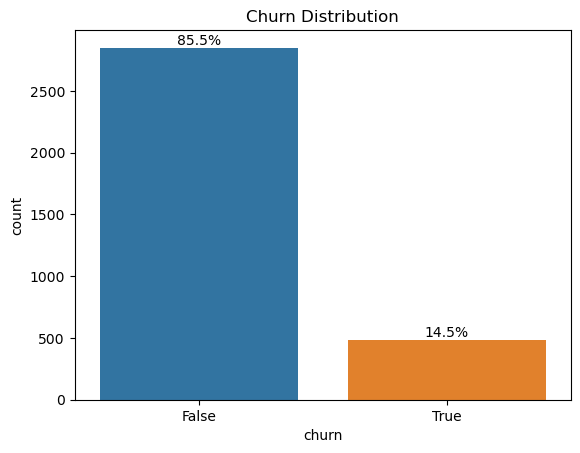

In [51]:
# Plot the distribution of 'churn'
ax = sns.countplot(data=df, x='churn')
plt.title("Churn Distribution")

# total number of records in df
total = len(df)

# Loop through each bar in the plot
for p in ax.patches:
    # Get the count (height) of each bar
    count = p.get_height()
    
    # Calculate the percentage that this count represents out of the total
    percentage = 100 * count / total
    
    # Add the percentage label above each bar
    ax.annotate(f'{percentage:.1f}%',              
                (p.get_x() + p.get_width() / 2.,   
                 count),                          
                ha='center', va='bottom')          

# Display the plot
plt.show()



As observed, the dataset shows a class imbalance, with a higher number of customers in the  not churned category with 85.5% and the churned having 14.5% . This imbalance highlights the need for techniques such as SMOTE during model training to ensure both classes are fairly represented.

### 1.1 Correlation Between Features and Churn
In this section, we examine the relationship between the churn variable and other features in the dataset to identify which attributes may influence a customer's likelihood of leaving. Understanding these correlations helps in selecting meaningful predictors for churn modeling.

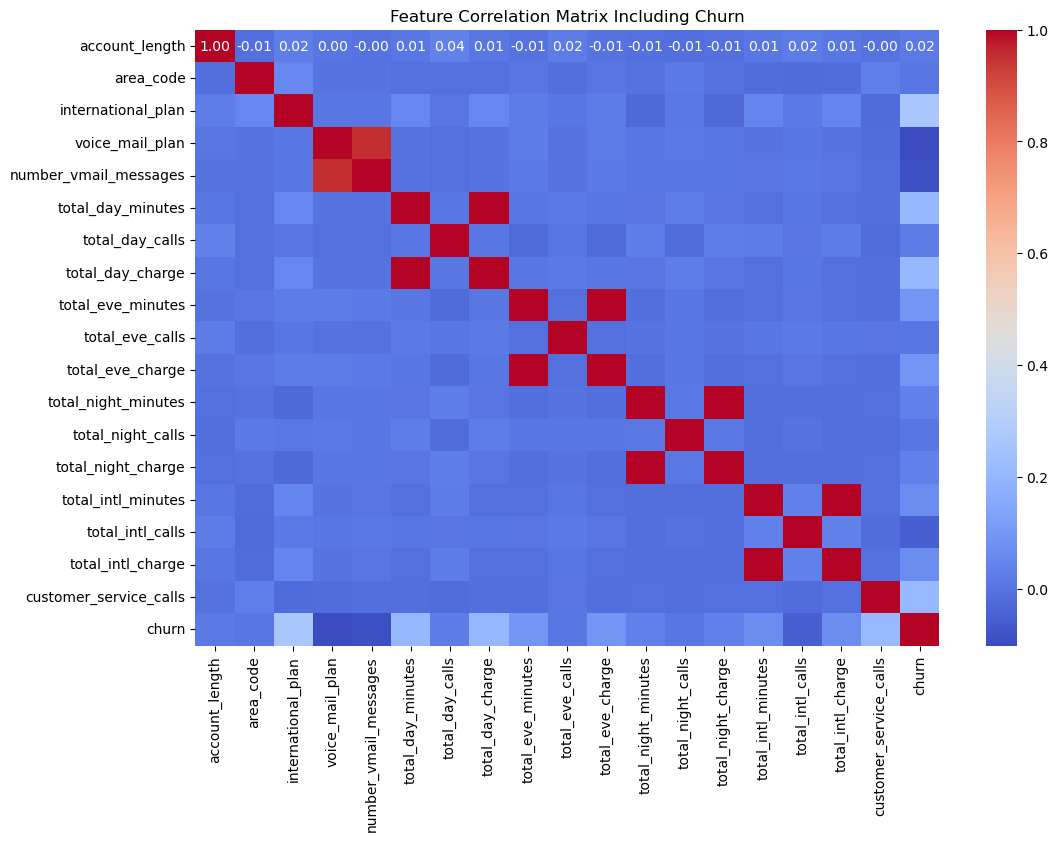


Correlation of features with churn:
churn                     1.000000
international_plan        0.259852
customer_service_calls    0.208750
total_day_minutes         0.205151
total_day_charge          0.205151
total_eve_minutes         0.092796
total_eve_charge          0.092786
total_intl_charge         0.068259
total_intl_minutes        0.068239
total_night_charge        0.035496
total_night_minutes       0.035493
total_day_calls           0.018459
account_length            0.016541
total_eve_calls           0.009233
area_code                 0.006174
total_night_calls         0.006141
total_intl_calls         -0.052844
number_vmail_messages    -0.089728
voice_mail_plan          -0.102148
Name: churn, dtype: float64


In [52]:
# Copy the DataFrame
df_corr = df.copy()

# Convert boolean churn column to numeric (0 and 1)
df_corr['churn'] = df_corr['churn'].astype(int)

# Select only numeric columns
numeric_df = df_corr.select_dtypes(include='number')

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix Including Churn")
plt.show()

# Print the correlation of all features with churn
print("\nCorrelation of features with churn:")
print(numeric_df.corr()['churn'].sort_values(ascending=False))


##  Correlation  between Features with Churn Intepretation

We analyzed the correlation between numeric features and the target variable `churn` (1 = Churned, 0 = Not Churned). Below is a summary of the key insights.

###  Top Positively Correlated Features

These features have the strongest **positive** relationship with churn.

| Feature                   | Correlation | Interpretation |
|---------------------------|-------------|----------------|
| `international_plan`      | **0.26**    | Customers with international plans are more likely to churn. |
| `customer_service_calls`  | **0.21**    | More service calls often indicate dissatisfaction. |
| `total_day_minutes`       | **0.21**    | High daytime usage may lead to higher bills and churn. |
| `total_day_charge`        | **0.21**    | Strongly related to `total_day_minutes`, same effect. |

---

###  Top Negatively Correlated Features

These features have a **negative** correlation with churn.

| Feature                  | Correlation | Interpretation |
|--------------------------|-------------|----------------|
| `voice_mail_plan`        | **-0.10**   | Voicemail plan users are less likely to churn. |
| `number_vmail_messages`  | **-0.09**   | More voicemails may signal engaged users. |
| `total_intl_calls`       | **-0.05**   | Weak negative association with churn. |


###  Features with Weak or No Correlation

The following features have minimal correlation with churn and might have low predictive value:

- `area_code` (0.006)
- `total_night_calls` (0.006)
- `total_eve_calls` (0.009)
- `account_length` (0.017)
- `total_day_calls` (0.018)


###  Note on Multicollinearity

Several feature pairs are highly correlated with each other (e.g., charges and their corresponding minutes). These may cause redundancy in models:

- `total_day_minutes` ↔ `total_day_charge`
- `total_eve_minutes` ↔ `total_eve_charge`
- `total_night_minutes` ↔ `total_night_charge`
- `total_intl_minutes` ↔ `total_intl_charge`

### 1.2 Top 10 Features Most Correlated with Churn

To determine the most influential numeric features for predicting churn, we calculated the Pearson correlation between each feature and the target variable, churn. Highlighting the top 10 correlated features allows us to focus on the variables that are most likely to impact customer retention.

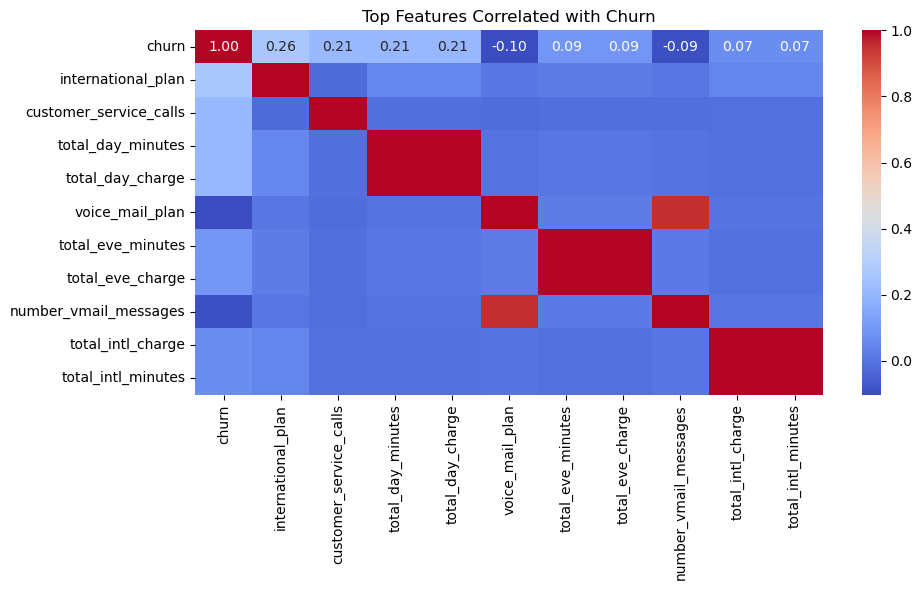


Correlation of Top 10features with churn:
churn                     1.000000
international_plan        0.259852
customer_service_calls    0.208750
total_day_minutes         0.205151
total_day_charge          0.205151
total_eve_minutes         0.092796
total_eve_charge          0.092786
total_intl_charge         0.068259
total_intl_minutes        0.068239
total_night_charge        0.035496
total_night_minutes       0.035493
total_day_calls           0.018459
account_length            0.016541
total_eve_calls           0.009233
area_code                 0.006174
total_night_calls         0.006141
total_intl_calls         -0.052844
number_vmail_messages    -0.089728
voice_mail_plan          -0.102148
Name: churn, dtype: float64


In [53]:
# Top 10 features most correlated with churn
top_corr = numeric_df.corr()['churn'].abs().sort_values(ascending=False).head(11).index  

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top Features Correlated with Churn')
plt.tight_layout()
plt.show()

print("\nCorrelation of Top 10features with churn:")
print(numeric_df.corr()['churn'].sort_values(ascending=False))


### Top 10 Features Most Correlated with Churn Intepretation

To better understand which features are most influential in predicting churn, we computed the Pearson correlation between each numeric variable and the churn variable. Below, we focus on the top features with the highest absolute correlation values.

As seen in the list below, the most positively correlated features with churn are:

- `international_plan` (0.26)
- `customer_service_calls` (0.21)
- `total_day_minutes` and `total_day_charge` (both 0.205)

Features with negative correlation `voice_mail_plan`, `number_vmail_messages` may also be informative in reducing churn likelihood.


### 2.1 Univariate Analysis - Numerical Features

In this section, we analyze the distribution of numerical features to understand the shape, spread, and possible outliers. We use histograms with KDE to visualize the data.

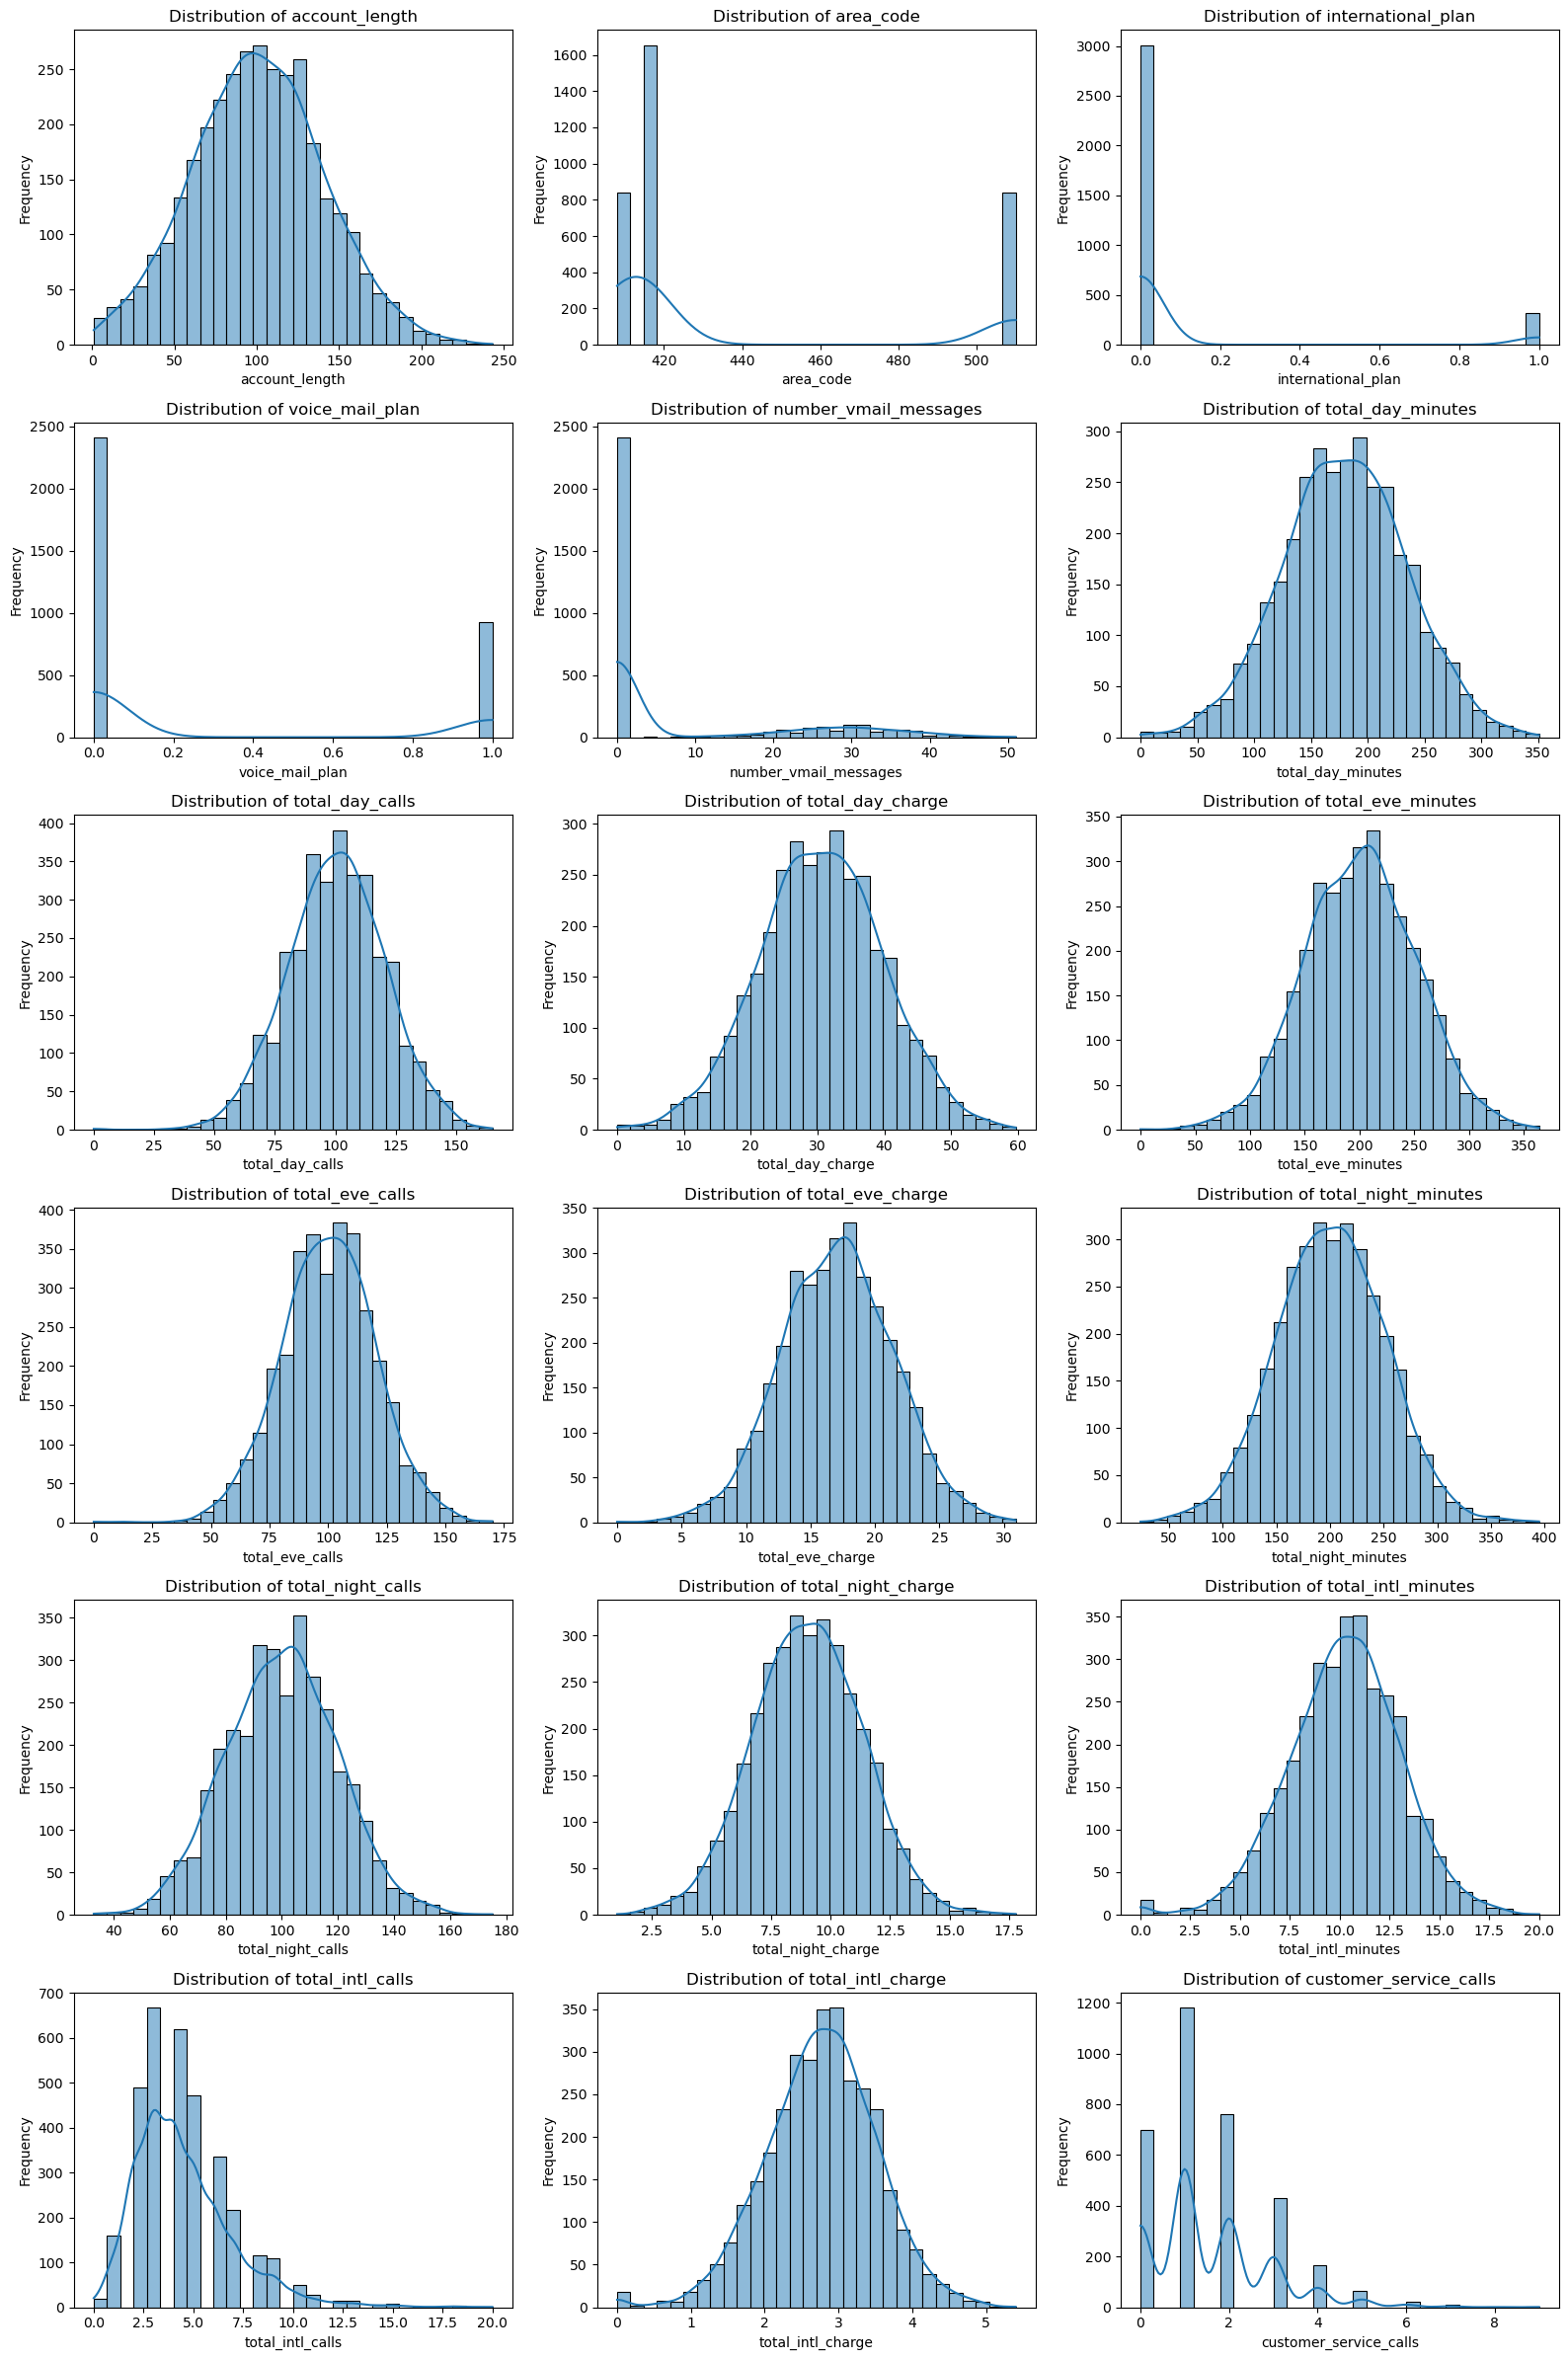

In [54]:
# Plot histograms with KDE for numerical features in a grid
numerical_cols = numeric_df.columns.drop('churn')  

n_cols = 3  # Number of plots per row
n_rows = -(-len(numerical_cols) // n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Univariate Analysis - Numerical Features Intepretation

The above plots help us identify features with skewed distributions, potential outliers, and possible transformations needed before modeling.

###  Feature Distribution Interpretation

- Most numerical features in the dataset display **normal distributions**, indicating that their values are symmetrically spread around the mean.

- **`area_code`** shows a **U-shaped distribution** with two visible peaks. The **right peak is higher than the left**, suggesting a larger concentration of customers from one particular area code.

- **`voice_mail_plan`** exhibits a **bimodal distribution**, typical for a binary feature. The two bars represent customers who either have or do not have a voicemail plan, with one category being more common.

- **`number_vmail_messages`** is mostly **concentrated around the middle**, but has a **long bar at 0**, indicating many customers don’t use voicemail at all.

- **`total_intl_calls`** and **`customer_service_calls`** are **right-skewed**, meaning that while most users make fewer calls in these categories, a small number of customers make significantly more.

- The **high bar at 0** for some features `number_vmail_messages` reflects a large population with **no activity**, which could be an important factor in churn prediction.


### 2.2 Univariate Analysis - Categorical Features

Next, we look at the distribution of categorical variables to see their frequencies and check for class imbalance or dominance.

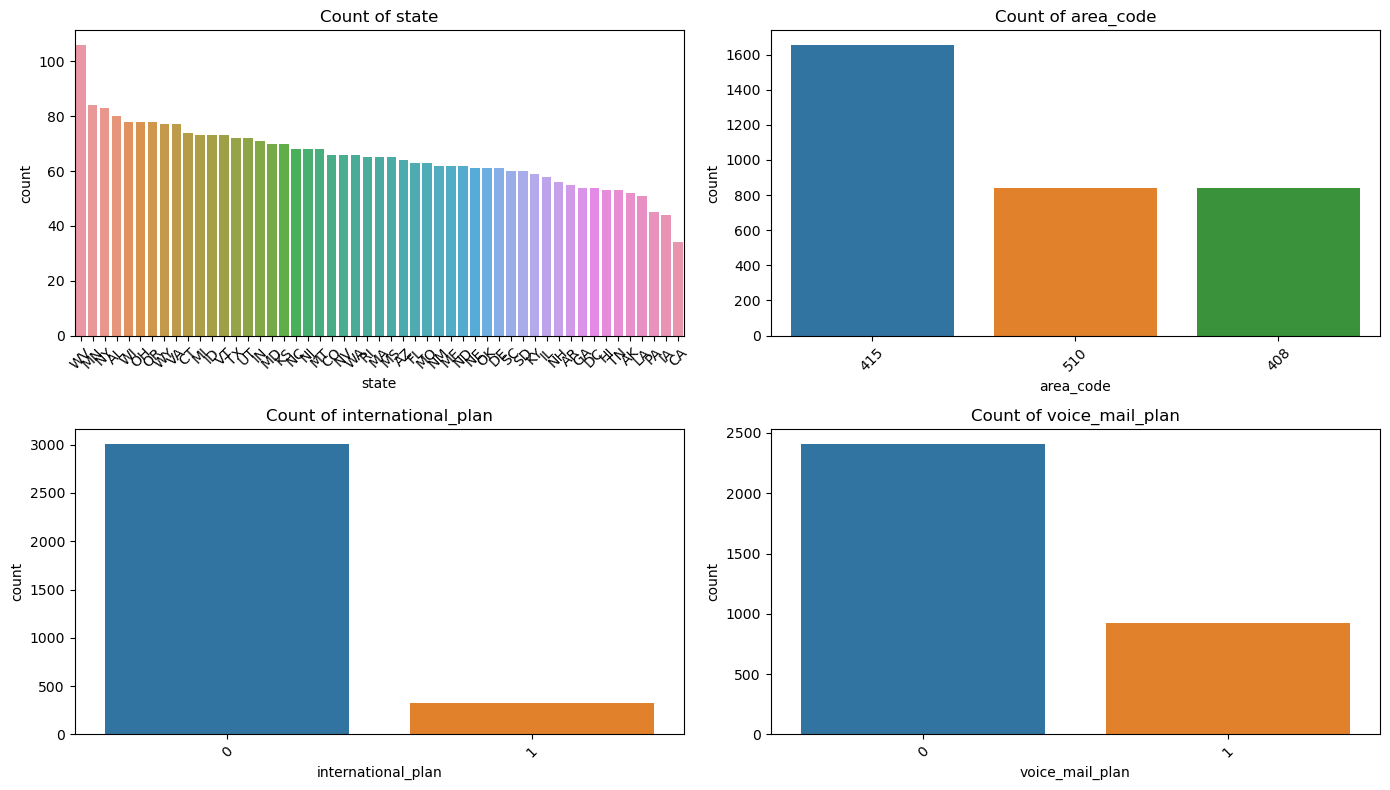

In [55]:
# Countplots for categorical columns
categorical_cols = ['state', 'area_code', 'international_plan', 'voice_mail_plan']

n_cols = 2
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Univariate Analysis - Categorical Features Intepretation

The categorical features state, area_code, international_plan, and voice_mail_plan—reveal patterns that could influence churn. State and area_code show uneven customer distribution, suggesting regional biases. Most users lack international or voicemail plans, indicating class imbalance and potential underuse. These distributions are important for identifying predictive features and ensuring balanced model training.


## 3.1 Bivariate Analysis: Churn Rate by State

To explore how customer churn varies geographically, we performed a bivariate analysis between the `state` feature and the target variable `churn`. We calculated the average churn rate per state by grouping the data and taking the mean of the churn column.

This helps identify whether customers in certain states are more likely to churn than others.

state
NJ    0.264706
CA    0.264706
TX    0.250000
MD    0.242857
SC    0.233333
MI    0.219178
MS    0.215385
NV    0.212121
WA    0.212121
ME    0.209677
MT    0.205882
AR    0.200000
KS    0.185714
NY    0.180723
MN    0.178571
PA    0.177778
MA    0.169231
CT    0.162162
NC    0.161765
NH    0.160714
GA    0.148148
DE    0.147541
OK    0.147541
OR    0.141026
UT    0.138889
CO    0.136364
KY    0.135593
SD    0.133333
OH    0.128205
FL    0.126984
IN    0.126761
ID    0.123288
WY    0.116883
MO    0.111111
VT    0.109589
AL    0.100000
NM    0.096774
ND    0.096774
WV    0.094340
TN    0.094340
DC    0.092593
RI    0.092308
WI    0.089744
IL    0.086207
NE    0.081967
LA    0.078431
IA    0.068182
VA    0.064935
AZ    0.062500
AK    0.057692
HI    0.056604
Name: churn, dtype: float64


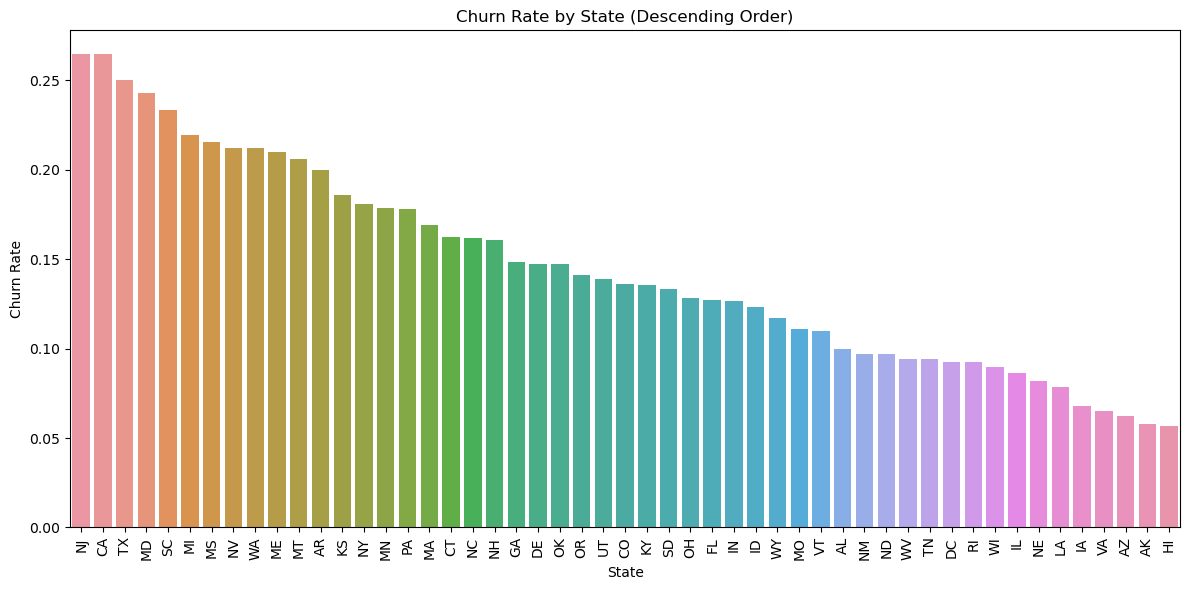

In [56]:
churn_by_state = df.groupby('state')['churn'].mean().sort_values(ascending=False)
print(churn_by_state)

# Calculate churn rate per state
churn_rate = df.groupby('state')['churn'].mean().reset_index()

# Sort by churn rate descending
churn_rate_sorted = churn_rate.sort_values(by='churn', ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=churn_rate_sorted, x='state', y='churn')
plt.xticks(rotation=90)
plt.title('Churn Rate by State (Descending Order)')
plt.ylabel('Churn Rate')
plt.xlabel('State')
plt.tight_layout()
plt.show()

### Bivariate Analysis: Churn Rate by State Interpretation:
The analysis of churn rates across different states reveals noticeable geographic variation in customer churn behavior. For instance, states like **New Jersey (NJ), California (CA), and Texas (TX)** show significantly higher churn rates compared to others.
This suggests that **geographic location may be correlated with churn**, potentially due to factors such as local competition, service quality, or customer preferences.

While the `state` feature may later be dropped during modeling due to its high cardinality and risk of introducing noise or overfitting, the insight it provides at this stage remains **valuable for business strategy**.

**Recommendations based on this insight:**
- Conduct **customer satisfaction surveys** or **service audits** in high-churn states.
- Launch **targeted retention campaigns** or promotional offers in states with high churn.
- Investigate whether **regional competitors, infrastructure issues, or demographic patterns** contribute to churn in these areas.


## 3.2 Bivariate Analysis - Numerical Features vs Churn

Here, we compare the distribution of each numerical feature across the churn values using boxplots. This helps in identifying which features vary significantly between churned and non-churned customers.

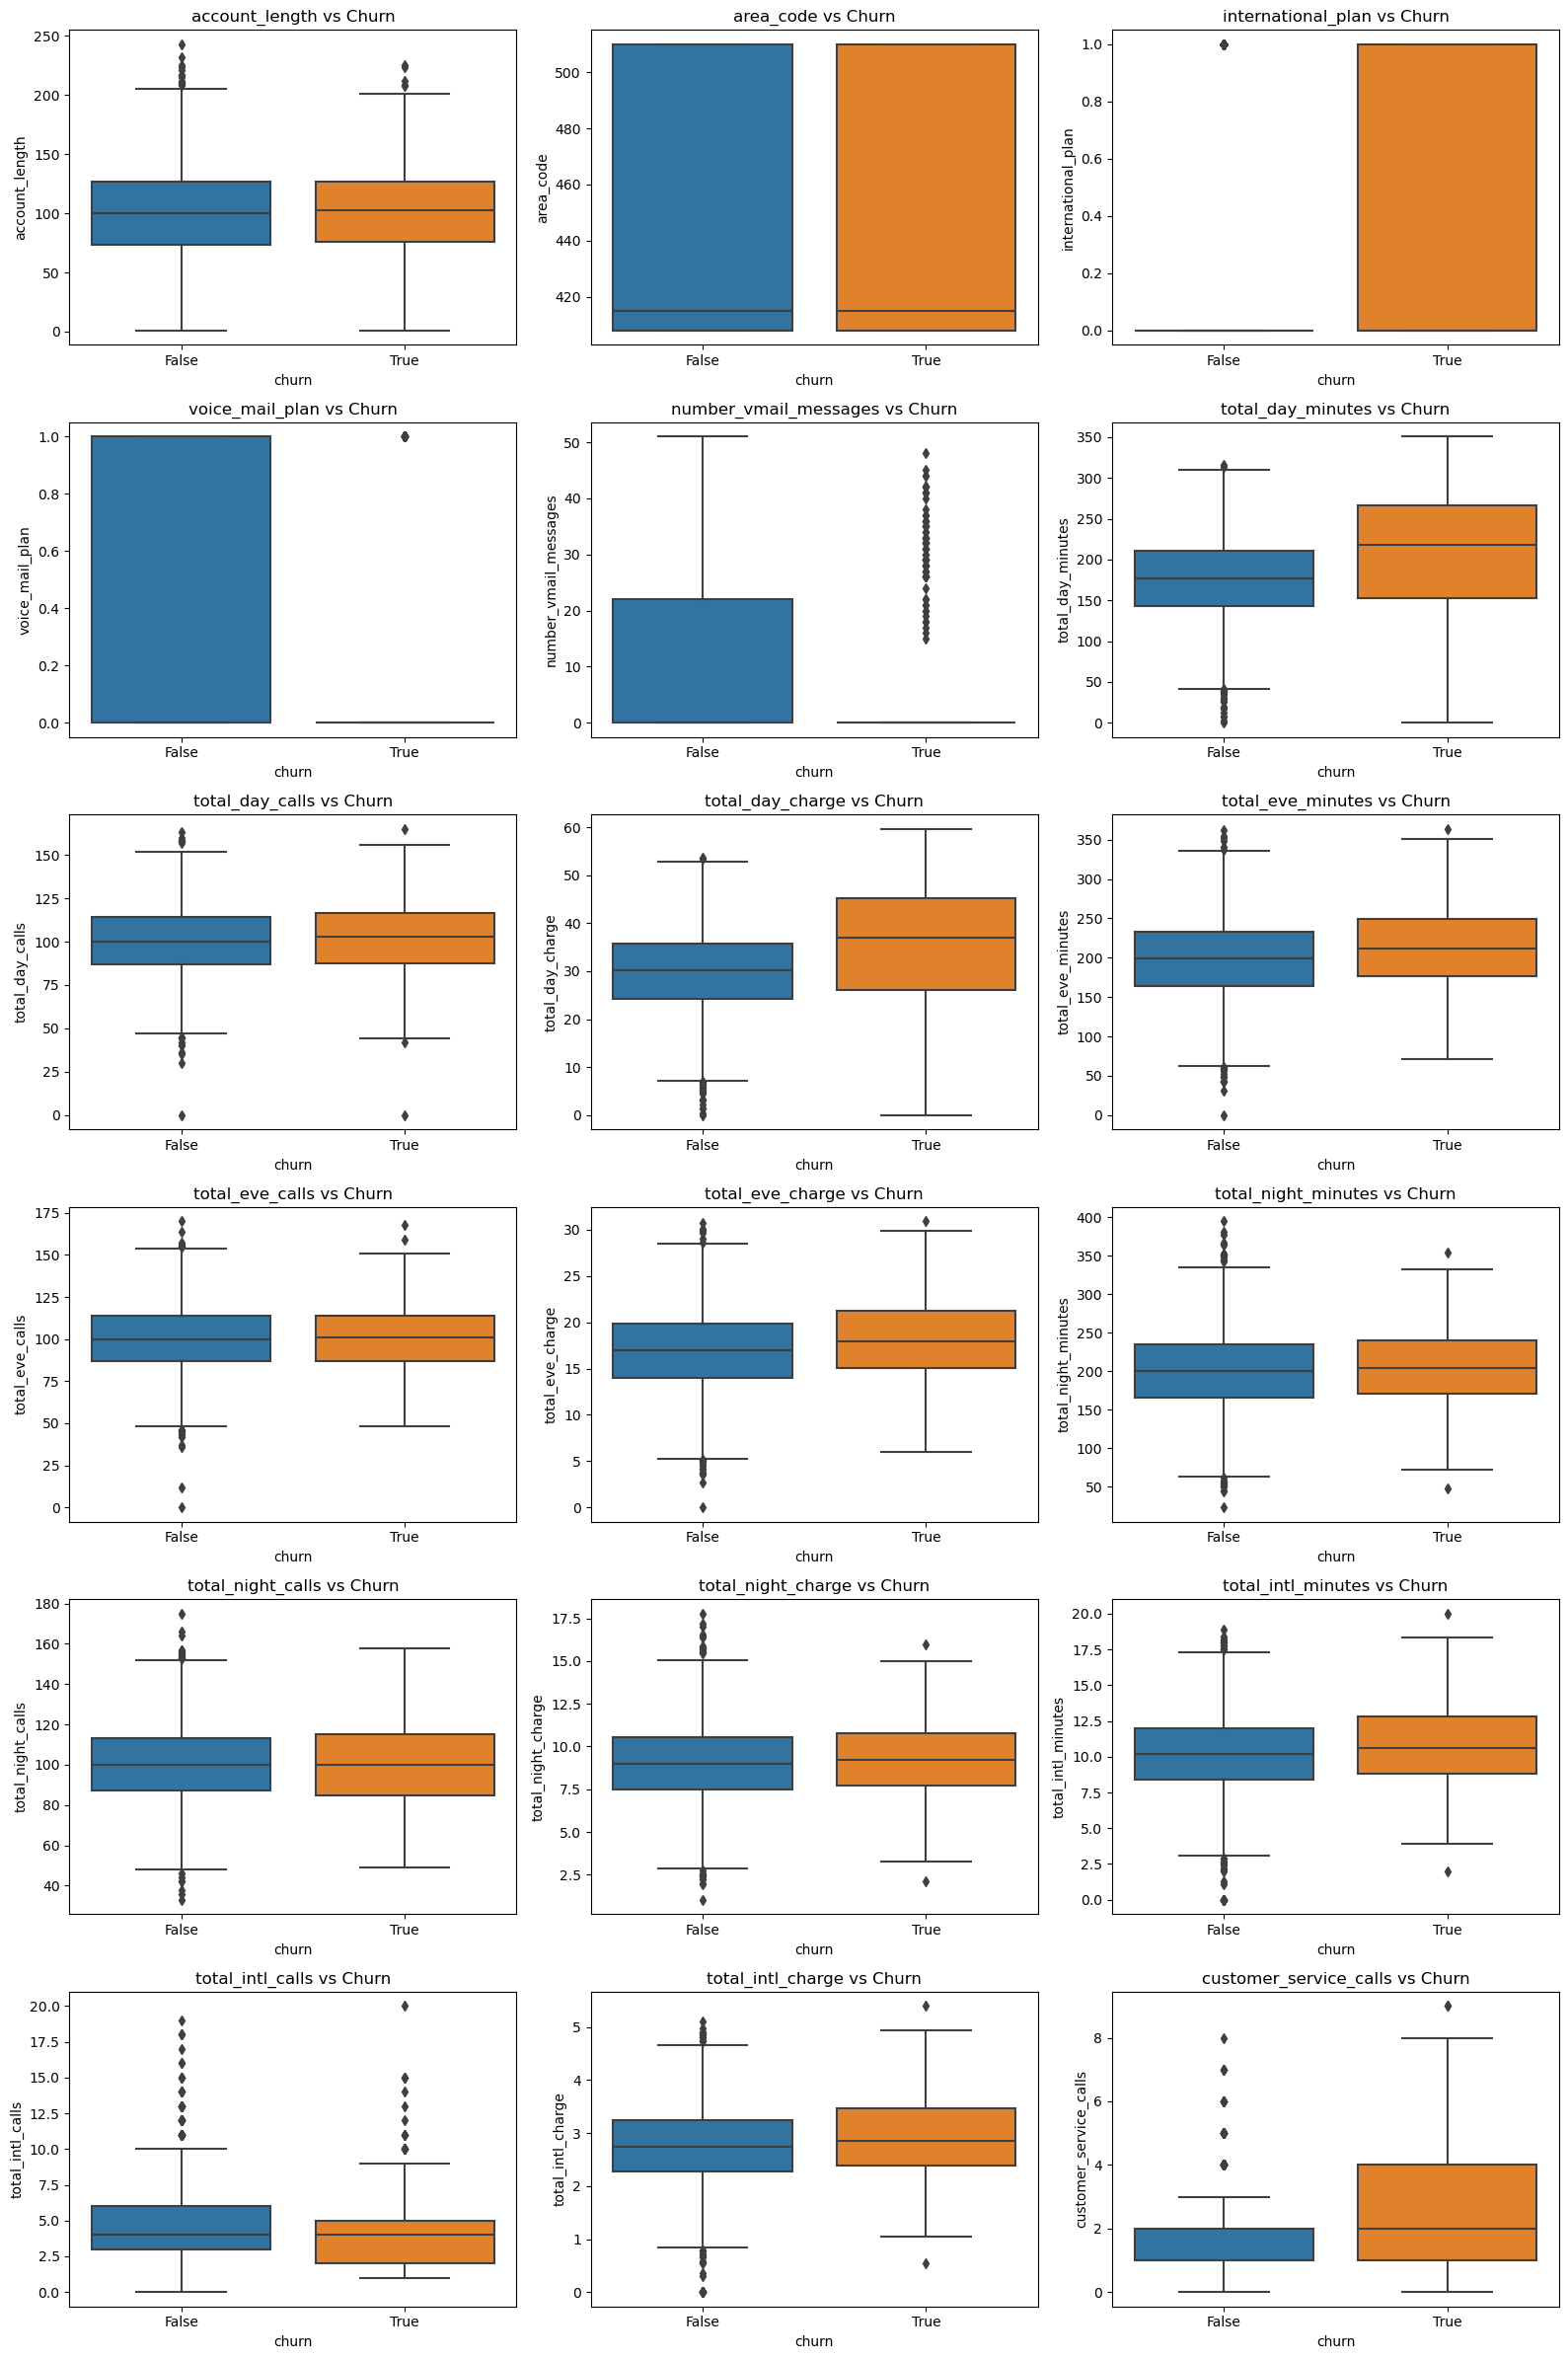

In [57]:
# Set the number of columns for the subplot grid
n_cols = 3

# Calculate the number of rows needed
n_rows = -(-len(numerical_cols) // n_cols)

# Create the subplots with the specified size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Loop through each numerical column to plot 
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='churn', y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")  # Set the title for each subplot

# remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()



## Bivariate Analysis - Numerical Features vs Churn Intepretation


1. **International Plan vs Churn**
- Customers with an **International Plan** are **more likely to churn**.
- This is a strong indicator of churn and should be considered in predictive modeling.

2. **Voice Mail Plan vs Churn**
- Customers **with a Voice Mail Plan** are **less likely to churn**.
- Suggests that such users may be more engaged or satisfied.

3. **Customer Service Calls vs Churn**
- Churners tend to have made **more customer service calls**.
- High interaction with support could be a red flag for dissatisfaction or unresolved issues.

4. **Number of Voicemail Messages**
- Non-churners tend to have **more voicemail messages**.
- Likely correlated with having a voicemail plan and more active usage.

Churners tend to have **higher usage and corresponding charges**:

- **Total Day Minutes & Total Day Charge**
- **Total Evening Minutes & Charges**
- **Total Night Minutes & Charges**
- **Total International Minutes & Charges**

- **Total Day Calls**, **Evening Calls**, and **Night Calls** show **no major difference** between churners and non-churners.
- **International Calls** are **slightly higher** for churners.

- **Account Length**: Slightly shorter for churners, but not a major difference.
- **Area Code**: No significant variation seen across churn status.


## 4.1  Total Charge vs Churn
We create a new feature, `total_charge`, by summing day, evening, night, and international charges. This can give a more holistic view of a customer's spending behavior.

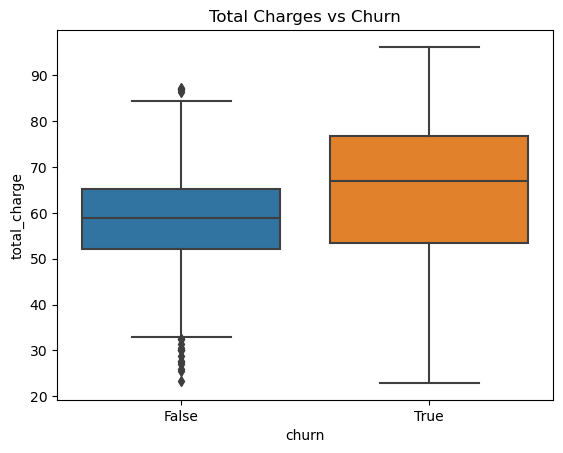

In [58]:
# Create total_charge 
df['total_charge'] = df[['total_day_charge', 'total_eve_charge', 
                       'total_night_charge', 'total_intl_charge']].sum(axis=1)

# Visualize relationship with churn
sns.boxplot(data=df, x='churn', y='total_charge')
plt.title('Total Charges vs Churn')
plt.show()

### Total Charge vs Churn Intepretation 

The boxplot shows that there's a noticeable difference in total charges between customers who churned and those who didn't churn with those with higher total charges being the most churners as compared to those with the least total charges. 

### 4.1.1 Binning Total Charges
To better understand how spending levels relate to churn, we discretize the `total_charge` feature into five equal-sized bins using quantile-based binning. This allows us to observe churn patterns across different customer spending groups.

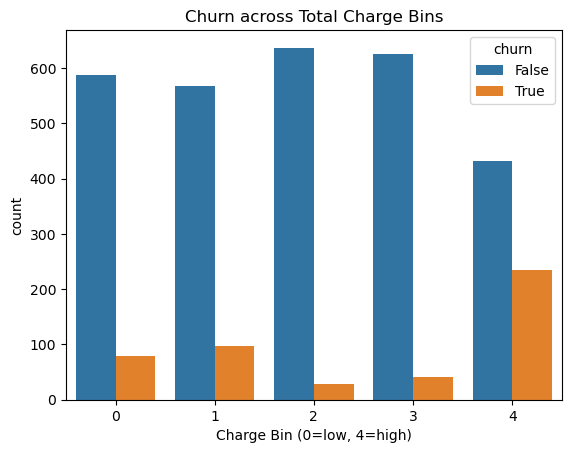

In [59]:
# Bin total charge into 5 equal-sized groups
df['churn'] = df['churn'].astype('string') 

df['charge_bin'] = pd.qcut(df['total_charge'], q=5, labels=False)

sns.countplot(data=df, x='charge_bin', hue='churn')
plt.title("Churn across Total Charge Bins")
plt.xlabel("Charge Bin (0=low, 4=high)")
plt.show()


### Binning Total Charges Intepretation

To explore how total charges relate to churn behavior, we binned the `total_charge` variable into five equal-sized groups and visualized the churn distribution within each bin:

- **Mid-range total charge bins** (around bin 2) show the **lowest churn rate**, suggesting stable and possibly more satisfied customers.
- **Customers in the highest total charge bin** (bin 4) exhibit a **significantly higher churn rate**, indicating potential dissatisfaction among high spenders.
- **Lower and moderate charge bins** (bins 0, 1, and 3) show varying churn patterns, with some increase in churn in lower-moderate groups.

 These insights highlight a **non-linear relationship** between total charges and churn:
- Spending more doesn't always mean higher satisfaction.
- Mid-range spenders appear to be the most retained.

### 5.1 Exploring Churn by Categorical Features

To understand how churn is related to specific service subscriptions, we examined the distribution of churn across two categorical variables:

- `international_plan`
- `voice_mail_plan`


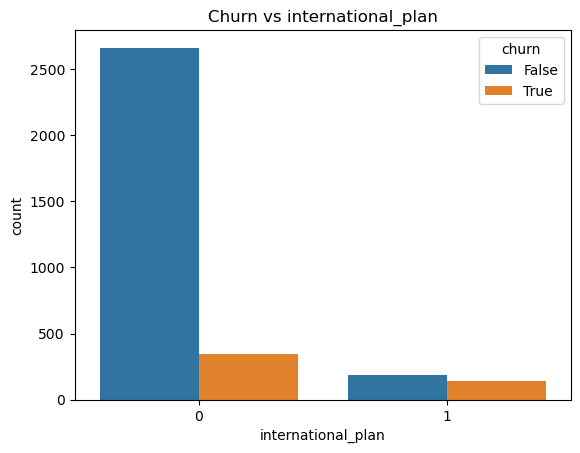

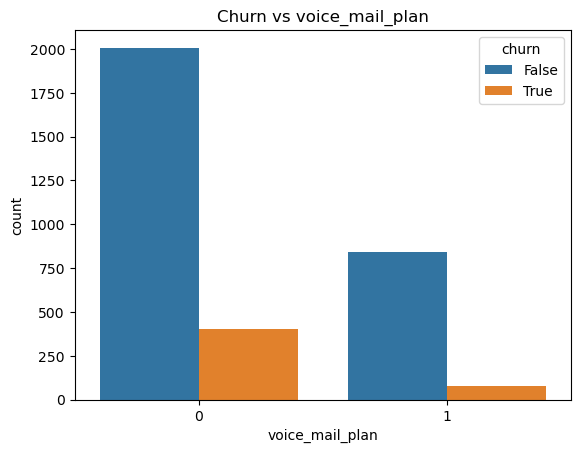

In [60]:
categorical_cols = ['international_plan', 'voice_mail_plan']

for col in categorical_cols:
    sns.countplot(data=df, x=col, hue='churn')
    plt.title(f'Churn vs {col}')
    plt.show()


### Exploring Churn by Categorical Features Intepretation

We analyzed how churn varies across two key categorical features:

- **International Plan**:
  - Customers subscribed to an international plan tend to churn at **higher rates** than those who are not.
  - This suggests that users with international plans might be less satisfied.

- **Voice Mail Plan**:
  - Customers with a voice mail plan tend to have a **lower churn rate** compared to those without.
  - This might indicate that customers using additional services are more engaged or find more value in their subscription.

In [61]:
# Drop 'state' and 'area_code' 
df.drop(['state', 'area_code'], axis=1, inplace=True)

We dropped the `state` and `area_code` features based on the following reasons:

- **High Cardinality (`state`)**: The `state` feature contains many unique value, which would result in a large number of one-hot encoded columns. This increases model complexity, introduces noise, and raises the risk of overfitting.
- Although `area_code` has only 3 unique values, it functions more as a regional tag than a behavior-driven variable. It showed little to no meaningful correlation with churn during exploratory analysis.
- Including these features led to poorer evaluation metrics and skewed feature importance with `state` dominating the model without offering actionable insights.
- After removing `state` and `area_code`, the model's performance improved and the important features became more aligned with customer behavior and service usage patterns.

##  Data Preprocessing

Before modeling, the dataset was preprocessed to ensure quality and consistency. This involved cleaning, encoding categorical variables, scaling numerical features, and handling class imbalance. 

#### Standardization of Numerical Features

To ensure that all numerical features contribute equally to the model and are on the same scale, we apply **standardization** using `StandardScaler`. This rescales features to have a mean of 0 and a standard deviation of 1.

We apply standardization only to **continuous numerical features**, excluding categorical or binary variables such as `international_plan`, and `voice_mail_plan`.

In [62]:
# Create a copy
df_scaled = df.copy()

# Columns to scale 
scale_cols = ['account_length', 'number_vmail_messages',
              'total_day_minutes', 'total_day_calls', 'total_day_charge',
              'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
              'total_night_minutes', 'total_night_calls', 'total_night_charge',
              'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
              'customer_service_calls']

scaler = StandardScaler()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

df_scaled[scale_cols].describe().T[['mean', 'std']]


,mean,std
account_length,1.470971e-16,1.00015
number_vmail_messages,7.035077e-17,1.00015
total_day_minutes,7.312216e-16,1.00015
total_day_calls,-1.934646e-16,1.00015
total_day_charge,-2.835349e-16,1.00015
total_eve_minutes,-6.821892e-17,1.00015
total_eve_calls,3.288365e-16,1.00015
total_eve_charge,1.385697e-16,1.00015
total_night_minutes,7.887813e-17,1.00015
total_night_calls,-4.903235e-17,1.00015


After standardization, all continuous numerical features are on a comparable scale.

### Comparing Feature Means by Churn

To understand which features contribute most to customer churn, we compare the average values of numerical features between churned and non-churned customers. This helps highlight key differences that may inform feature selection and model training.

In [63]:
# Compare feature means between churned and non-churned customers
churn_group_means = df.groupby('churn').mean(numeric_only=True).T

# Compute difference between True (churned) and False (not churned)
churn_group_means['diff'] = churn_group_means['True'] - churn_group_means['False']

# Display top 10 features that differ the most
churn_group_means.sort_values('diff', ascending=False).head(10)


churn,False,True,diff
total_day_minutes,175.175754,206.914079,31.738324
total_eve_minutes,199.043298,212.410145,13.366847
total_charge,58.448807,65.355963,6.907156
total_day_charge,29.780421,35.175921,5.395500
total_night_minutes,200.133193,205.231677,5.098484
account_length,100.793684,102.664596,1.870912
total_eve_charge,16.918909,18.054969,1.136060
total_day_calls,100.283158,101.335404,1.052246
customer_service_calls,1.449825,2.229814,0.779989
charge_bin,1.910526,2.523810,0.613283


### Interpretation of Feature Mean Differences

The table above shows the **top 10 numerical features** with the greatest mean differences between customers who churned (`True`) and those who did not (`False`).

- **`total_day_minutes`** shows the largest difference: churned customers use significantly more daytime minutes on average (+31.7 minutes), suggesting that high day usage could be linked to churn.
- **`total_eve_minutes`**, **`total_charge`**, and **`total_day_charge`** are also higher among churned users, indicating heavier overall usage may be a churn indicator.
- **`customer_service_calls`** is noticeably higher for churned customers (~2.2 vs ~1.4), hinting that service issues might drive customer dissatisfaction.
- Features like **`account_length`** and **`total_day_calls`** show smaller differences but still rank in the top 10, suggesting limited but non-negligible correlation with churn.
- The **`charge_bin`** variable also shows that churned customers tend to fall into higher charge brackets.

These insights are helpful for **feature selection**. Features like `total_day_minutes`, `customer_service_calls`, and `total_charge` may be particularly useful in predicting churn and should be prioritized during modeling or further explored through visualizations.


### Churn Class Distribution (%)

We examine the class balance of the target variable `churn` to understand if there's an imbalance. This is critical when choosing appropriate modeling strategies.

In [64]:
# Check value counts
df_scaled['churn'].value_counts(normalize=True) * 100


churn
False    85.508551
True     14.491449
Name: proportion, dtype: Float64

**Interpretation:**  
The dataset is **highly imbalanced**, with only about **14.5% of customers having churned**. This suggests that standard models may be biased toward predicting the majority class (`False` = no churn).  

### Preparing the Target Variable for Modeling

Before training a machine learning model, the target variable `churn` must be converted from categorical (`True`/`False`) to numeric (`1`/`0`). 

In [65]:
le = LabelEncoder()
df['churn'] = le.fit_transform(df['churn'])

### Multicollinearity Check using VIF

To assess multicollinearity among numerical features, we calculate the **Variance Inflation Factor (VIF)**. A high VIF indicates that a feature is highly correlated with other features, which can impact model interpretability and stability.

This step helps in deciding whether to remove or combine certain features before modeling.


In [66]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Only include numerical features
X = df[numerical_cols].drop(columns=['churn'], errors='ignore')

X_const = add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))] 

print(vif_data)


                   feature           VIF
0           account_length  1.004518e+00
1       international_plan  1.008387e+00
2          voice_mail_plan  1.191925e+01
3    number_vmail_messages  1.192006e+01
4        total_day_minutes  1.049421e+07
5          total_day_calls  1.004766e+00
6         total_day_charge           inf
7        total_eve_minutes  2.239170e+06
8          total_eve_calls  1.002573e+00
9         total_eve_charge           inf
10     total_night_minutes  6.389648e+05
11       total_night_calls  1.003940e+00
12      total_night_charge           inf
13      total_intl_minutes  6.909755e+04
14        total_intl_calls  1.004767e+00
15       total_intl_charge           inf
16  customer_service_calls  1.003963e+00
17            total_charge           inf
18              charge_bin  8.682306e+00


### Multicollinearity Check Using VIF

To ensure that our model is not affected by multicollinearity, we used the **Variance Inflation Factor (VIF)**.

We calculated the VIF for each feature and obtained the following insights:

- Several features had **infinite VIF values**:
  - `total_day_charge`, `total_eve_charge`, `total_night_charge`, `total_intl_charge`, and `total_charge`.
  - These are **perfectly collinear** with their respective minute-based features (`*_minutes`). 
- `voice_mail_plan` and `number_vmail_messages` both had VIFs around **11.9**, indicating strong correlation.
- `charge_bin` had a VIF of approximately **8.68**, likely due to its dependence on `total_charge`.

### Dropping Features with High Multicollinearity

We used VIF (Variance Inflation Factor) to check for multicollinearity. Features with very high VIFs indicate strong linear relationships with other variables, which can negatively affect model performance.

In [67]:
# columns to drop
columns_to_drop = [
    'charge_bin',
    'total_day_charge',      # Perfect correlation with total_day_minutes
    'total_eve_charge',      # Perfect correlation with total_eve_minutes  
    'total_night_charge',    # Perfect correlation with total_night_minutes
    'total_intl_charge',     # Perfect correlation with total_intl_minutes
    'total_charge',          # Sum of all charges 
    'number_vmail_messages'  # Redundant with voice_mail_plan
]

columns_found = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_found)

# Display column names
print("Remaining columns after cleaning:")
print(df.columns.tolist())
print(f"\nColumns dropped: {columns_found}")
print(f"Total features remaining: {len(df.columns)}")


Remaining columns after cleaning:
['account_length', 'international_plan', 'voice_mail_plan', 'total_day_minutes', 'total_day_calls', 'total_eve_minutes', 'total_eve_calls', 'total_night_minutes', 'total_night_calls', 'total_intl_minutes', 'total_intl_calls', 'customer_service_calls', 'churn']

Columns dropped: ['charge_bin', 'total_day_charge', 'total_eve_charge', 'total_night_charge', 'total_intl_charge', 'total_charge', 'number_vmail_messages']
Total features remaining: 13


### Feature Removal for Multicollinearity Issues

- **5 features** have **infinite VIF** (perfect multicollinearity)
- **4 features** have **VIF > 10** (high multicollinearity)
- **1 feature** has **VIF ≈ 8.7** (moderate multicollinearity)

 **Charge-Related Features** 
- `total_day_charge`, `total_eve_charge`, `total_night_charge`, `total_intl_charge`, `total_charge` This is because they are directly calculated from minute features.

 **Derived Categorical Feature**
- `charge_bin`
- **Why**: Created from `total_charge`, inherits its multicollinearity. VIF ≈ 8.7

 **Voicemail Feature**
- `number_vmail_messages`
- **Why**: Highly correlated with `voice_mail_plan` (VIF ≈ 11.9)

In [68]:
# Separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Check balance in y_train and y_test
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


Train class distribution:
churn
0    0.855214
1    0.144786
Name: proportion, dtype: float64

Test class distribution:
churn
0    0.854573
1    0.145427
Name: proportion, dtype: float64


The training and testing sets have nearly identical churn class proportions:

- **Train set**:  
  - Class 0 (Not Churned): ~85.52%  
  - Class 1 (Churned): ~14.48%

- **Test set**:  
  - Class 0 (Not Churned): ~85.46%  
  - Class 1 (Churned): ~14.54%

This is happened because we used **stratified splitting**, which ensures the class distribution remains consistent across both sets. This helps produce more reliable and fair model training and evaluation results since our dataset is imbalanced.


### Addressing Class Imbalance with SMOTE

Our class distribution shows a significant imbalance, with only ~15% of churned customers. To prevent our models from being biased towards the majority class, we apply **SMOTE (Synthetic Minority Over-sampling Technique)**.

**Key points:**
- SMOTE synthetically generates new samples from the minority class.
- We apply it **only to the training set** to avoid data leakage.
- This ensures the model has enough churn examples to learn meaningful patterns.

The result is a more balanced training set, which improves the performance of models on minority class predictions.


In [69]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new class balance
print("After SMOTE, training class distribution:")
print(y_train_resampled.value_counts(normalize=True))


After SMOTE, training class distribution:
churn
0    0.5
1    0.5
Name: proportion, dtype: float64


### Class Distribution After SMOTE

After applying SMOTE (Synthetic Minority Oversampling Technique), the training set is now balanced, with both classes having equal representation:

- **Churn = 0 (No Churn):** 50%
- **Churn = 1 (Churn):** 50%

This balance helps address the class imbalance problem in the original dataset (where churned customers were only ~14.5%) and ensures that the model doesn't become biased towards predicting the majority class. It provides a better foundation for training models that can generalize well to both classes.


## Modelling
In this phase, we will build a model that can predict the customer churn based on the features in our dataset. The model will be evaluated on the recall score. Specifically, if it achieves an recall score of 75% or higher, it will be considered a success.

### Logistic Regression Model Training

We begin by training a Logistic Regression model on the SMOTE balanced dataset.


In [70]:
# Initialize the logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model to the SMOTE-balanced data
logreg.fit(X_train_resampled, y_train_resampled)


LogisticRegression(max_iter=1000, random_state=42)

In [71]:

#  Make predictions on the original test set
y_pred = logreg.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78       570
           1       0.27      0.68      0.38        97

    accuracy                           0.68       667
   macro avg       0.60      0.68      0.58       667
weighted avg       0.83      0.68      0.73       667


 Confusion Matrix:
[[388 182]
 [ 31  66]]


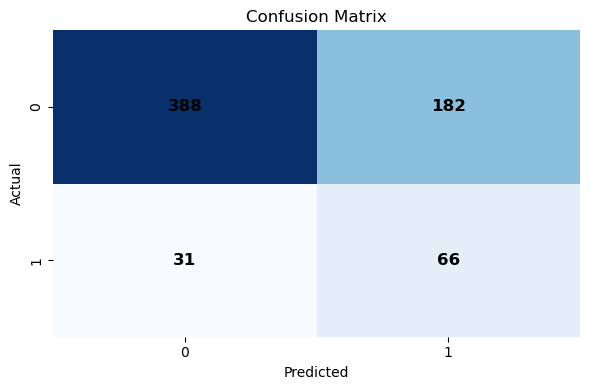


 ROC AUC Score: 0.768


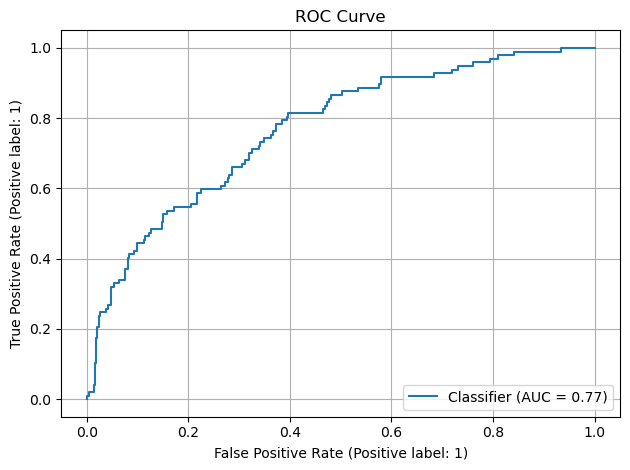

In [72]:
#  Generate predictions and probabilities
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

# Classification Report
print(" Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix 
plt.figure(figsize=(6, 4))
ax = sns.heatmap(cm, cmap='Blues', cbar=False, xticklabels=[0, 1], yticklabels=[0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha='center', va='center', color='black', fontsize=12, fontweight='bold')


plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#  ROC AUC Score 
print(f"\n ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# Plot ROC Curve 
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve")
plt.grid(True)
plt.tight_layout()
plt.show()



## Model Evaluation Summary

| Class                   | Precision | Recall | F1-Score | Support |
|------------------------|-----------|--------|----------|---------|
| **0** (Majority Class) | 0.93      | 0.68   | 0.78     | 570     |
| **1** (Minority Class) | 0.27      | 0.68   | 0.38     | 97      |

- **Accuracy**: `0.68`  
- **Macro Average**: Precision = `0.60`, Recall = `0.68`, F1-score = `0.58`  
- **Weighted Average**: Precision = `0.83`, Recall = `0.68`, F1-score = `0.73`

### Confusion Matrix Interpretation

- **True Negatives (TN):** 388  
- **False Positives (FP):** 182  
- **False Negatives (FN):** 31  
- **True Positives (TP):** 66

### ROC AUC Score

- **ROC AUC Score:** `0.768`  
- Indicates **moderate model performance** 


###  Feature Importance Analysis (Logistic Regression)

In this step, we analyze and visualize which features had the most influence on the model’s predictions. This helps interpret the model by identifying which input variables contribute most to the prediction of churn.


                   Feature  Coefficient  Abs_Coefficient
2          voice_mail_plan    -1.919426         1.919426
1       international_plan     0.835224         0.835224
11  customer_service_calls     0.521060         0.521060
10        total_intl_calls    -0.178991         0.178991
9       total_intl_minutes     0.124054         0.124054
3        total_day_minutes     0.011368         0.011368
5        total_eve_minutes     0.007273         0.007273
4          total_day_calls     0.004140         0.004140
0           account_length     0.002167         0.002167
7      total_night_minutes     0.001713         0.001713


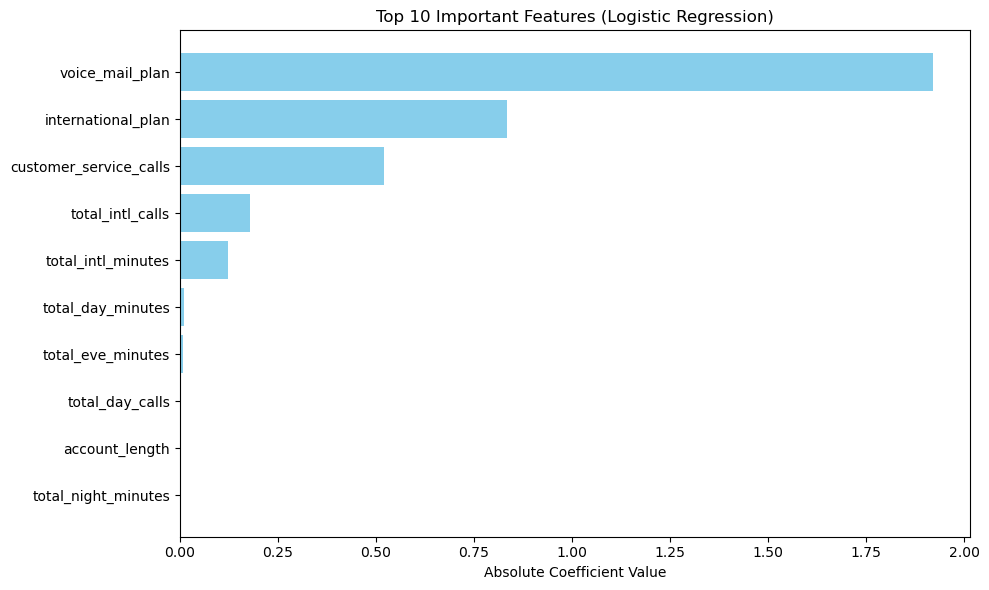

In [73]:
# Get feature names
feature_names = X_train.columns

# Get the coefficients from the logistic regression model
coefficients = logreg.coef_[0]

# Create a DataFrame of features and their importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute importance
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Display top features
print(importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Abs_Coefficient'][:10], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


### Logistic Regression Coefficients Interpretation

The table below presents the estimated coefficients from a logistic regression model trained on SMOTE-balanced data. These coefficients indicate the **influence of each feature on the likelihood of churn**. A positive coefficient means the feature increases the probability of churn, while a negative coefficient decreases it.

| Feature                  | Coefficient | Interpretation |
|--------------------------|-------------|----------------|
| `voice_mail_plan`        | -1.919      | Customers with a voicemail plan are **much less likely to churn**. This is the most influential feature. |
| `international_plan`     | +0.835      | Customers with an international plan are **more likely to churn**, possibly due to unexpected or higher charges. |
| `customer_service_calls` | +0.521      | More customer service calls increase churn risk, likely due to unresolved complaints or dissatisfaction. |
| `total_intl_calls`       | -0.179      | Customers making more international calls are **slightly less likely to churn**, suggesting they are more engaged. |
| `total_intl_minutes`     | +0.124      | More international call duration **slightly increases** churn risk. |
| `total_day_minutes`      | +0.011      | Longer daytime call duration has **minimal impact**, slightly increasing churn. |
| `total_eve_minutes`      | +0.007      | Evening call duration shows very little effect, with a **slight increase** in churn risk. |
| `total_day_calls`        | +0.004      | The number of daytime calls has a **negligible positive** effect on churn. |
| `account_length`         | +0.002      | Longer account history has **very minor influence** on churn, suggesting customer tenure isn't a major factor. |
| `total_night_minutes`    | +0.002      | Nighttime usage has almost **no effect** on churn risk. |


## Transitioning to Decision Tree Classifier

After evaluating a Logistic Regression model with balanced training data, we now explore a **Decision Tree Classifier** as an alternative model. This step is important because:

-  **Decision Trees** can capture **non-linear relationships** that Logistic Regression might miss.
-  They are **interpretable**, allowing us to understand decision-making paths.
-  They handle **feature interactions** naturally without needing explicit interaction terms.
-  They also work well with **imbalanced datasets**, especially after SMOTE resampling.

In [74]:
# Initialize and train the Decision Tree
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train_resampled, y_train_resampled)

# Predict class labels
y_pred_tree = dtree.predict(X_test)

# Predict probabilities for ROC AUC
y_proba_tree = dtree.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nROC AUC Score:", roc_auc_score(y_test, y_proba_tree))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       570
           1       0.57      0.73      0.64        97

    accuracy                           0.88       667
   macro avg       0.76      0.82      0.79       667
weighted avg       0.90      0.88      0.89       667


Confusion Matrix:
[[517  53]
 [ 26  71]]

ROC AUC Score: 0.8368240188099115


## Decision Tree Model Evaluation Summary

###  Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| **0** (Majority) | 0.95 | 0.91 | 0.93 | 570 |
| **1** (Minority) | 0.57 | 0.73 | 0.64 | 97 |

- **Accuracy:** `0.88`
- **Macro Avg:** Precision = `0.76`, Recall = `0.82`, F1-Score = `0.79`
- **Weighted Avg:** Precision = `0.90`, Recall = `0.88`, F1-Score = `0.89`

###  Interpretation

- The model performs **exceptionally well for class 0** with high precision and recall.
- **Class 1 (minority class)** has a **strong recall (0.73)** and **moderate precision (0.57)** 

###  Confusion Matrix

|              | Predicted 0 | Predicted 1 |
|--------------|-------------|-------------|
| Actual 0     | 517 (TN)    | 53 (FP)      |
| Actual 1     | 26 (FN)     | 71 (TP)     |


###  ROC AUC Score

- **ROC AUC:** `0.836`
- This indicates **strong model performance** with good separation between the two classes.

###  Feature Importance Analysis (Decision Tree)

This section identifies the top features that the Decision Tree model relied on most when making predictions. This helps us understand which features the tree considered most informative in predicting customer churn.


                   Feature  Importance
3        total_day_minutes    0.362119
11  customer_service_calls    0.228183
2          voice_mail_plan    0.140190
5        total_eve_minutes    0.100943
1       international_plan    0.057569
10        total_intl_calls    0.056084
9       total_intl_minutes    0.034366
7      total_night_minutes    0.014772
0           account_length    0.002818
6          total_eve_calls    0.002687


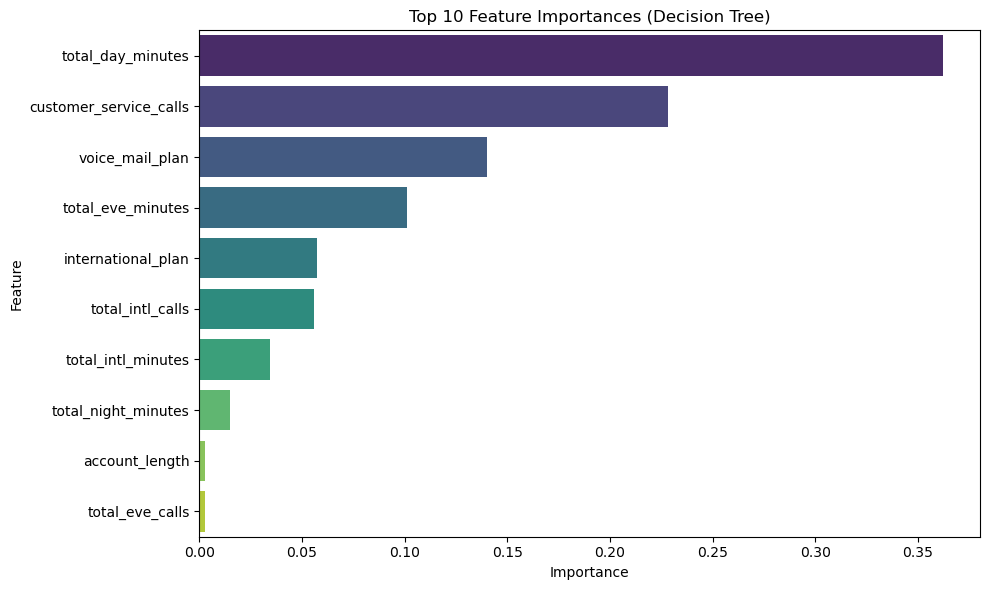

In [75]:
# Get feature importances
importances = dtree.feature_importances_

# Create a DataFrame
tree_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display
print(tree_importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=tree_importance_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()


###  Feature Importance

- **total_day_minutes (0.3621)**: Most influential — longer daytime call durations are strongly associated with churn behavior.
- **customer_service_calls (0.2282)**: High number of service calls often signals dissatisfaction → higher churn likelihood.
- **voice_mail_plan (0.1402)**: Having or not having a voicemail plan significantly affects churn tendencies.
- **total_eve_minutes (0.1009)**: Evening call time moderately influences churn — possibly tied to personal usage habits.
- **international_plan (0.0576)**: Customers with or without international plans show different churn patterns.
- **total_intl_calls (0.0561)**: Number of international calls provides modest predictive power.
- **total_intl_minutes (0.0344)**: Similar to intl calls — supports the churn trend from international usage behavior.
- **total_night_minutes (0.0148)**: Weak influence — night usage has minor relation to churn.
- **account_length (0.0028)**: Nearly negligible — how long someone’s been a customer has minimal predictive value.
- **total_eve_calls (0.0027)**: Very low impact — total number of evening calls contributes little to prediction.



##  Random Forest Classifier

After evaluating our **Logistic Regression** and **Decision Tree** models, we now introduce  **Random Forest** to improve performance and reduce overfitting.

In [76]:
# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Fit on SMOTE-resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]


In [77]:
# Classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_proba_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       570
           1       0.59      0.61      0.60        97

    accuracy                           0.88       667
   macro avg       0.76      0.77      0.76       667
weighted avg       0.88      0.88      0.88       667


Confusion Matrix:
[[529  41]
 [ 38  59]]

ROC AUC Score:
0.8601193705914271



**Interpretation:**

- **Class 0 (Majority Class):**  
  - Precision, recall, and F1-score are all **0.93**, indicating excellent performance in correctly predicting the majority class.
- **Class 1 (Minority Class):**  
  - Precision is **0.59**: 59% of predicted class 1 values were correct.  
  - Recall is **0.61**: 61% of actual class 1 values were correctly identified.  
  - F1-score of **0.60** reflects a reasonable balance between precision and recall for the minority class, showing improvement from earlier models.

- **Overall Accuracy:** **0.88** (88%) of all predictions were correct.
- **Macro Average F1-Score:** **0.76**, which treats both classes equally and indicates balanced performance.
- **Weighted Average F1-Score:** **0.88**, accounting for class imbalance (heavily influenced by class 0 performance).


- The ROC AUC score of **0.86** suggests that the model does a **good job at distinguishing between the two classes**, with an 86% chance that a randomly chosen positive instance ranks higher than a randomly chosen negative one.


                   Feature  Importance
3        total_day_minutes    0.240311
11  customer_service_calls    0.110838
5        total_eve_minutes    0.106703
9       total_intl_minutes    0.078349
2          voice_mail_plan    0.076988
7      total_night_minutes    0.075727
0           account_length    0.062688
4          total_day_calls    0.057942
6          total_eve_calls    0.057486
10        total_intl_calls    0.056331


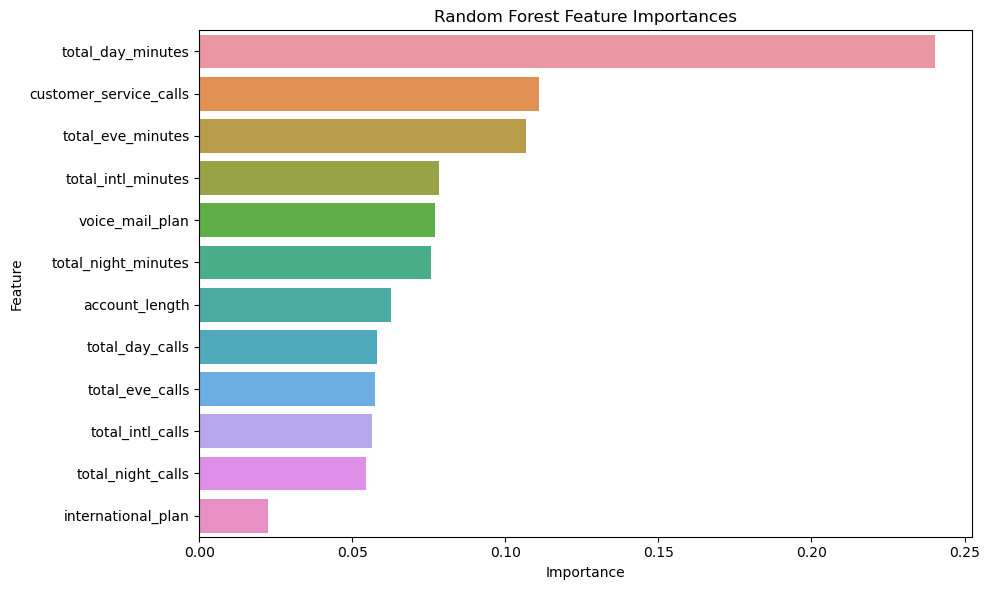

In [78]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


# Display
print(importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()


##  Feature Importance Interpretation - Random Forest Model

The feature importance scores help us understand which variables had the greatest impact on the model's decision-making process. Here's how the features ranked:

- `total_day_minutes` is the most influential feature, contributing over **24%** of the decision-making power in the model.
- `customer_service_calls` also plays a significant role, indicating that customer dissatisfaction or frequent support contact may be a predictor of churn.
- `voice_mail_plan` and various usage-related metrics (e.g., evening and international minutes) have moderate importance, implying customer behavior patterns are useful for prediction.
- Less influential features like `total_intl_calls` and `total_eve_calls` still contribute, but to a smaller extent.

##  Model Evaluation & Comparison

We evaluate all models using consistent metrics to determine the best performing algorithm for churn prediction.

Metrics used:
- **Accuracy**: Overall correctness
- **Recall (for churn)**: How many churners were caught
- **Precision (for churn)**: How many predicted churners were correct
- **ROC AUC Score**: Overall class separation capability


In [79]:
# Function to evaluate a classification model
def evaluate_model(name, model, X_test, y_test):
    # Predict labels and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)          
    rec = recall_score(y_test, y_pred)             
    prec = precision_score(y_test, y_pred)        
    auc = roc_auc_score(y_test, y_prob)            

    # Print results
    print(f"{name}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"ROC AUC: {auc:.3f}")
    print("")

    # Return results as a dictionary
    return {
        "Model": name,
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "AUC": auc
    }

# Evaluate multiple models and store results
results = []
results.append(evaluate_model("Logistic Regression", logreg, X_test, y_test))
results.append(evaluate_model("Decision Tree", dtree, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))


Logistic Regression
Accuracy: 0.681
Recall: 0.680
Precision: 0.266
ROC AUC: 0.768

Decision Tree
Accuracy: 0.882
Recall: 0.732
Precision: 0.573
ROC AUC: 0.837

Random Forest
Accuracy: 0.882
Recall: 0.608
Precision: 0.590
ROC AUC: 0.860



In [80]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall", ascending=False)  


,Model,Accuracy,Recall,Precision,AUC
1,Decision Tree,0.881559,0.731959,0.572581,0.836824
0,Logistic Regression,0.680660,0.680412,0.266129,0.768023
2,Random Forest,0.881559,0.608247,0.590000,0.860119


##  Model Evaluation and Comparison

To determine the best performing classification model for our dataset, we evaluated the following three algorithms:
- **Logistic Regression**
- **Decision Tree**
- **Random Forest**

Each model was assessed using key metrics:
- **Accuracy** – overall correctness of predictions  
- **Recall** – ability to capture all true positives  
- **Precision** – accuracy of the positive predictions  
- **ROC AUC** – the model’s ability to distinguish between classes

These metrics were especially important due to the class imbalance in our data.

- **Logistic Regression** has the lowest performance across all metrics. While it's a good baseline, its low precision (0.266) and ROC AUC (0.768) indicate it struggles with the minority class.
  
- **Decision Tree** shows strong overall performance with the **highest recall (0.732)**, meaning it's better at identifying churners compared to the others. Precision is reasonable (0.573), and AUC is competitive.

- **Random Forest** offers the best **ROC AUC (0.860)**, indicating strong class separation capability. Precision is slightly higher than Decision Tree, but **recall is lower**, making it less ideal if catching churners is a top priority.


##  Hyperparameter Tuning

To improve model performance, we perform hyperparameter tuning using `RandomizedSearchCV`.

In [81]:
# Parameter grid for Decision Tree
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize base model and search
dt = DecisionTreeClassifier(random_state=42)
dt_random_search = RandomizedSearchCV(
    estimator=dt, 
    param_distributions=dt_param_grid,
    n_iter=50,
    scoring='roc_auc', 
    cv=5, 
    n_jobs=-1, 
    random_state=42
)

# Fit and get best model
dt_random_search.fit(X_train_resampled, y_train_resampled)
best_dtree = dt_random_search.best_estimator_

print(f"Best Parameters: {dt_random_search.best_params_}")

# Predict class labels
y_pred_tuned_tree = best_dtree.predict(X_test)
# Predict probabilities for ROC AUC
y_proba_tuned_tree = best_dtree.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned_tree))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_tree))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba_tuned_tree))



Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10, 'criterion': 'gini'}
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       570
           1       0.55      0.68      0.61        97

    accuracy                           0.87       667
   macro avg       0.75      0.79      0.77       667
weighted avg       0.89      0.87      0.88       667


Confusion Matrix:
[[516  54]
 [ 31  66]]

ROC AUC Score: 0.8212334961114125


###  Tuned Decision Tree - Results Analysis

**Hyperparameter Search Results:**
The RandomizedSearchCV identified the following optimal parameters for our Decision Tree:

```
Best Parameters: {
    'criterion': 'gini',
    'max_depth': 10,
    'min_samples_split': 20,
    'min_samples_leaf': 2,
    'max_features': None
}
```

**Performance Comparison:**

| Metric | Baseline DT | Tuned DT | Change |
|--------|-------------|----------|--------|
| **ROC AUC** | 0.837 | 0.821 | **-0.016** |
| **Accuracy** | 88.2% | 87.0% | -1.2% |
| **Precision** | 57.3% | 55.0% | -2.3% |
| **Recall** | 73.2% | 68.0% | -5.2% |


**Conservative Tuning Strategy**: The algorithm chose more restrictive parameters (`min_samples_split=20`, `min_samples_leaf=2`) to prevent overfitting, but this came at the cost of predictive power.
**Depth vs Control Trade-off**: While the tree was allowed to grow deeper (max_depth=10), the stricter splitting rules limited its ability to capture complex patterns.
**Baseline Was Well-Optimized**: The slight performance decrease suggests that the baseline `max_depth=5` was already near-optimal for this dataset.
**Recall Reduction**: The model became more conservative in predicting churn, missing more actual churners (68% vs 73.2% recall).

**Baseline Decision Tree**: More aggressive at identifying potential churners (higher recall)
**Tuned Decision Tree**: More cautious approach, potentially reducing false alarms but missing some real churners

The tuning process revealed that our baseline Decision Tree parameters were already well-suited for this churn prediction task. The slight performance decrease indicates that simpler models may be more effective for this particular dataset, avoiding the complexity that can lead to overfitting.

In [82]:
# Parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5],
    'bootstrap': [True, False]
}

# Initialize base model and search
rf = RandomForestClassifier(random_state=42)
rf_random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=rf_param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5, 
    n_jobs=-1, 
    random_state=42
)

# Fit and get best model
rf_random_search.fit(X_train_resampled, y_train_resampled)
best_rf = rf_random_search.best_estimator_

print(f"Best Parameters: {rf_random_search.best_params_}")

# Predict class labels
y_pred_tuned_rf = best_rf.predict(X_test)
# Predict probabilities for ROC AUC
y_proba_tuned_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rf))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba_tuned_rf))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       570
           1       0.63      0.66      0.64        97

    accuracy                           0.89       667
   macro avg       0.78      0.80      0.79       667
weighted avg       0.90      0.89      0.89       667


Confusion Matrix:
[[532  38]
 [ 33  64]]

ROC AUC Score: 0.8774190631217219


                   Feature  Importance
3        total_day_minutes    0.295250
11  customer_service_calls    0.196034
5        total_eve_minutes    0.132582
2          voice_mail_plan    0.103487
10        total_intl_calls    0.072204
7      total_night_minutes    0.051097
1       international_plan    0.043678
9       total_intl_minutes    0.033475
4          total_day_calls    0.024492
6          total_eve_calls    0.022071


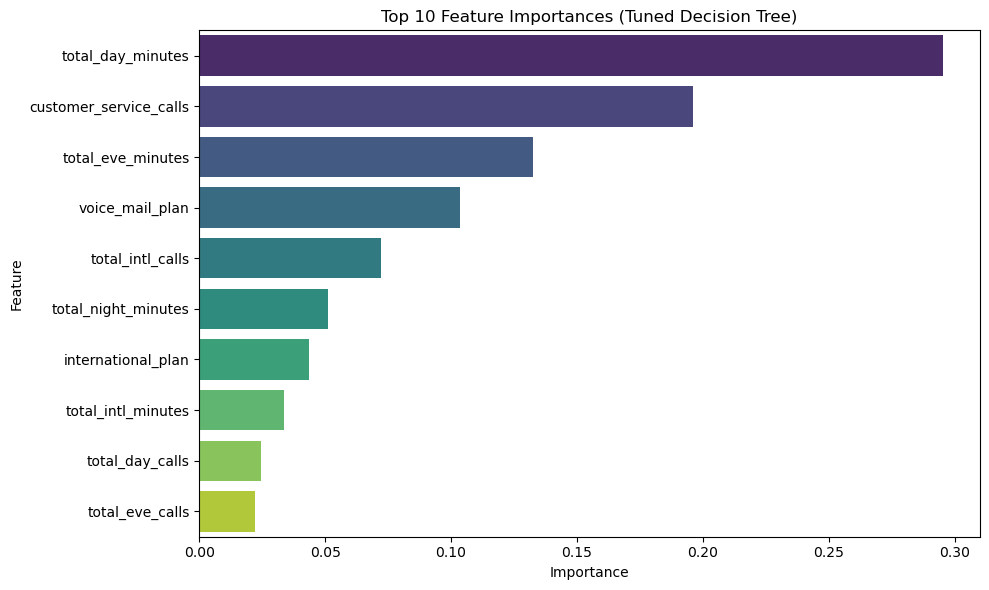


 TUNED RANDOM FOREST FEATURE IMPORTANCE:
                   Feature  Importance
3        total_day_minutes    0.259330
11  customer_service_calls    0.115156
5        total_eve_minutes    0.107346
2          voice_mail_plan    0.085761
7      total_night_minutes    0.072951
9       total_intl_minutes    0.069983
0           account_length    0.057183
10        total_intl_calls    0.057105
4          total_day_calls    0.053112
6          total_eve_calls    0.050928


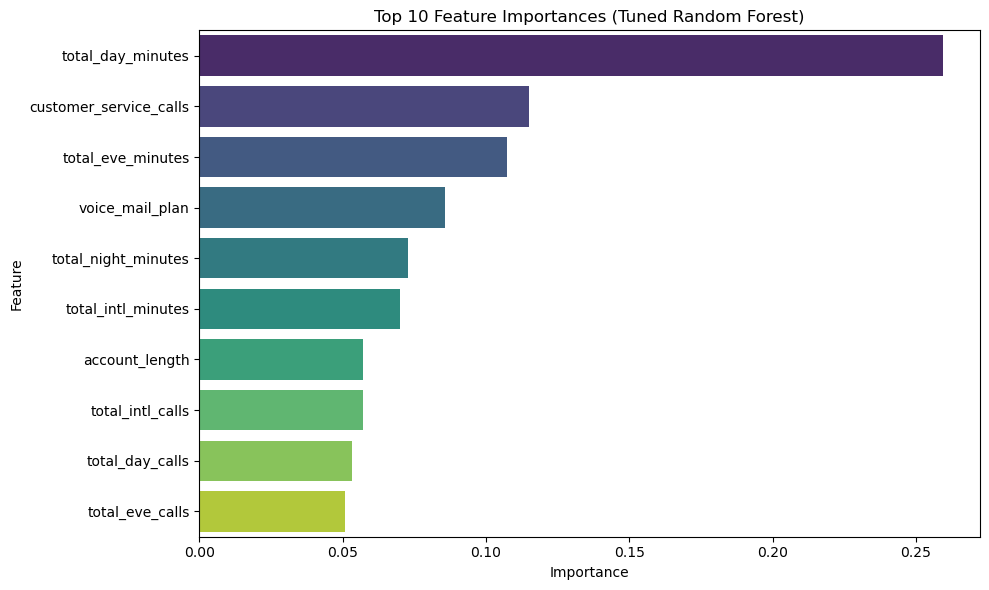

In [83]:
tuned_dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dtree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(tuned_dt_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=tuned_dt_importance.head(10), palette='viridis')
plt.title("Top 10 Feature Importances (Tuned Decision Tree)")
plt.tight_layout()
plt.show()

# Tuned Random Forest Feature Importance
print("\n TUNED RANDOM FOREST FEATURE IMPORTANCE:")
tuned_rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(tuned_rf_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=tuned_rf_importance.head(10), palette='viridis')
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.tight_layout()
plt.show()

##  Feature Importance Analysis 

### **1. Usage Patterns are THE Primary Churn Predictor**
- **Total day minutes** dominates both models
- **Evening/night minutes** also highly predictive
- **Business Insight**: Heavy daytime users are more likely to churn.

### **2. Customer Service Calls
- **2nd most important feature** in both models
- **Business Implication**: Customers calling support frequently are at high churn risk
- **Actionable Insight**: Proactive support outreach needed for customers with 2+ service calls

### **3. Service Plans Matter Significantly**
- **Voice mail plan** consistently 3rd-4th most important feature
- **International plan** also highly predictive 
- **Business Meaning**: Plan type/service tier strongly correlates with churn behavior

### **4. Account Tenure Provides Stability**
- **Account length** appears in Random Forest top features
- **Insight**: Newer customers more likely to churn 

In [84]:
# Compare all models including tuned versions
final_results = []
final_results.append(evaluate_model("Logistic Regression", logreg, X_test, y_test))
final_results.append(evaluate_model("Decision Tree", dtree, X_test, y_test))
final_results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
final_results.append(evaluate_model("Tuned Decision Tree", best_dtree, X_test, y_test))
final_results.append(evaluate_model("Tuned Random Forest", best_rf, X_test, y_test))

final_df = pd.DataFrame(final_results)
print(final_df.sort_values(by=["Recall", "AUC"], ascending=False))

Logistic Regression
Accuracy: 0.681
Recall: 0.680
Precision: 0.266
ROC AUC: 0.768

Decision Tree
Accuracy: 0.882
Recall: 0.732
Precision: 0.573
ROC AUC: 0.837

Random Forest
Accuracy: 0.882
Recall: 0.608
Precision: 0.590
ROC AUC: 0.860

Tuned Decision Tree
Accuracy: 0.873
Recall: 0.680
Precision: 0.550
ROC AUC: 0.821

Tuned Random Forest
Accuracy: 0.894
Recall: 0.660
Precision: 0.627
ROC AUC: 0.877

                 Model  Accuracy    Recall  Precision       AUC
1        Decision Tree  0.881559  0.731959   0.572581  0.836824
3  Tuned Decision Tree  0.872564  0.680412   0.550000  0.821233
0  Logistic Regression  0.680660  0.680412   0.266129  0.768023
4  Tuned Random Forest  0.893553  0.659794   0.627451  0.877419
2        Random Forest  0.881559  0.608247   0.590000  0.860119


# Churn Prediction Model Summary & Business Impact
We've tested multiple ML models to predict customer churn. The **Decision Tree** model delivers the best **recall (73.2%)**, helping us identify ~3 in 4 churners — critical for retention efforts.

## Model Comparison

| Model                 | Accuracy | Recall | Precision | ROC AUC | Recommendation     |
|----------------------|----------|--------|-----------|---------|--------------------|
| **Decision Tree**   | 88.2%    | **73.2%** | 57.3%     | 83.7%   | **Best (High Recall)** |
| Tuned Random Forest  | **89.4%**| 66.0%  | **62.7%** | **87.7%**| Good alternative    |
| Random Forest        | 88.2%    | 60.8%  | 59.0%     | 86.0%   | Balanced            |
| Tuned Decision Tree  | 87.3%    | 68.0%  | 55.0%     | 82.1%   | Decent              |
| Logistic Regression  | 68.1%    | 68.0%  | 26.6%     | 76.8%   | Poor precision      |

### Why Decision Tree

- **Highest Recall**: Captures the most churners.
- **Business Friendly**: Simple and interpretable.
- **Low Cost Risk**: False positives are manageable

We’ve built a strong foundation with high recall models. Now, optimizing the threshold will maximize **real-world value**. The Decision Tree is interpretable, cost-effective, and ready for deployment with minor adjustments.


In [85]:
# Get predicted probabilities for churners
y_probs = dtree.predict_proba(X_test)[:, 1]

# Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Find threshold with the best F1-score
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

# Predict using both default (0.5) and optimized threshold
y_pred_default = dtree.predict(X_test)
y_pred_optimized = (y_probs >= best_thresh).astype(int)

#  comparison
print(f" Optimal Threshold: {best_thresh:.3f}")
print(f" Default Recall: {recall_score(y_test, y_pred_default):.3f}")
print(f" Improved Recall: {recall_score(y_test, y_pred_optimized):.3f}")
print(f" Improved F1-Score: {f1_score(y_test, y_pred_optimized):.3f}")

# Confusion Matrix for optimized threshold
print("\n Confusion Matrix (Optimized Threshold):")
print(confusion_matrix(y_test, y_pred_optimized))

# Classification report
print("\n Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_optimized))

 Optimal Threshold: 0.421
 Default Recall: 0.732
 Improved Recall: 0.753
 Improved F1-Score: 0.655

 Confusion Matrix (Optimized Threshold):
[[517  53]
 [ 24  73]]

 Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       570
           1       0.58      0.75      0.65        97

    accuracy                           0.88       667
   macro avg       0.77      0.83      0.79       667
weighted avg       0.90      0.88      0.89       667




##  Threshold Tuning Interpretation – Decision Tree

###  Optimal Threshold: **0.421**
We adjusted the default threshold to **0.421**. This means that if the model predicts a customer has a **42.1% or higher** chance of churning, we now classify them as a "churner" — instead of waiting for it to be at least 50%.

###  Key Metrics 

| Metric        | Default | Tuned (0.421) | Change       |
|---------------|---------|---------------|--------------|
| Recall (Churn) | 0.732   | **0.753**     |  Improved |
| F1-Score       | ~0.64   | **0.655**     |  Improved |

- **Recall (Churn)**: Increased slightly — we're now catching more actual churners.
- **F1-Score**: Improved — we're balancing precision and recall better.


###  Confusion Matrix (Optimized Threshold)

- **True Negatives (517)**: Non-churners correctly predicted.
- **False Positives (53)**: Non-churners wrongly predicted as churners.
- **False Negatives (24)**: Churners missed by the model.
- **True Positives (73)**: Churners correctly identified.


###  Classification Report Summary (Optimized)

- **Class 0 (Non-churners)**:
  - Precision: 0.96 → Very few false positives.
  - Recall: 0.91 → Most non-churners are correctly identified.

- **Class 1 (Churners)**:
  - Precision: 0.58 → Some false alarms (non-churners predicted as churners).
  - Recall: 0.75 → We're catching 75% of churners — a strong improvement.

- **Accuracy**: 88% → Overall model is still highly accurate.
- **Macro Avg (Unweighted)**: Balanced performance across both classes.
- **Weighted Avg**: High overall performance, reflecting class imbalance.


###  Business Insight

- **Churners caught**: 73 out of 97 → **75.3%**
- **False alarms**: 53 customers wrongly predicted to churn.
- **Net gain**: We catch more churners with only a small increase in false alarms, helping retain more customers who might leave.

> This trade-off can be good for customer retention strategies — better to flag a few extra customers than miss out on actual churners.

##  Model Interpretation & Insights

After testing multiple classifiers, we selected the **Decision Tree Classifier** as the final model. This choice was based on its strong performance and interpretability.

###  Why Decision Tree?
- It achieved a good balance between precision and recall.
- Easy to interpret and explain to non-technical stakeholders.
- Allows threshold tuning to prioritize specific metrics like recall.

###  Threshold Tuning Results
To better capture the minority class (label `1`), we optimized the classification threshold:

- **Optimal Threshold:** 0.421  
- **Default Recall:** 0.732  
- **Improved Recall:** 0.753  
- **Improved F1-Score:** 0.655  
- **ROC-AUC Score:** 0.836  

###  Confusion Matrix (Optimized Threshold)


## Business Impact of Churn Predictions

To translate our churn predictions into business value, we estimated the potential revenue impact using our decision tree model's optimized predictions.

This analysis translates machine learning churn predictions into actionable business insight using:
- Our model's predictions (`y_pred_optimized`)
- Actual test labels (`y_test`) 
- Original charge columns from raw data


In [110]:
# Create new df
financial_df = df_raw.loc[X_test.index].copy()

# Add the predicted churn labels to the Df
financial_df['Predicted_Churn'] = y_pred_optimized

# Add the actual churn labels to the DataFrame for comparison
financial_df['Actual_Churn'] = y_test  

charge_columns = ['total day charge', 'total eve charge', 
                  'total night charge', 'total intl charge']

# Calculate total monthly charge
financial_df['total_monthly_charge'] = financial_df[charge_columns].sum(axis=1)

def calculate_impact(df):
    tp = df[(df['Predicted_Churn'] == 1) & (df['Actual_Churn'] == 1)]
    fp = df[(df['Predicted_Churn'] == 1) & (df['Actual_Churn'] == 0)]
    fn = df[(df['Predicted_Churn'] == 0) & (df['Actual_Churn'] == 1)]

    # Return a dictionary with financial and performance metrics
    return {
        # Estimated annual revenue at risk from churners correctly identified
        'Annual_At_Risk': tp['total_monthly_charge'].sum() * 12,

        # Cost of wrongly predicted churners 
        'False_Positive_Cost': len(fp) * 50,  

        # Revenue lost due to not identifying actual churners
        'Missed_Revenue': fn['total_monthly_charge'].sum() * 12,

        # Recall: proportion of actual churners correctly predicted
        'Recall': len(tp) / (len(tp) + len(fn))
    }

# impact based on the financial_df
impact = calculate_impact(financial_df)

print(f" Annual Revenue at Risk: ${impact['Annual_At_Risk']:,.2f}")
print(f" False Positive Costs: ${impact['False_Positive_Cost']:,.2f}")
print(f" Missed Churn Revenue: ${impact['Missed_Revenue']:,.2f}")
print(f" Recall Rate: {impact['Recall']:.1%}")


 Annual Revenue at Risk: $59,243.04
 False Positive Costs: $2,650.00
 Missed Churn Revenue: $19,056.84
 Recall Rate: 75.3%


###  Model Financial Impact Interpretation

####  Annual Revenue at Risk: $59,243.04
- This is the **estimated annual revenue you could lose** from customers who were predicted to churn and **actually did churn** (True Positives).
- It’s based on their **total monthly charges × 12 months**.
- This figure shows how much money is at stake, even when churn is predicted correctly.

####  False Positive Costs: $2,650.00
- This is the **cost of incorrectly predicting churn** for customers who would have **actually stayed** (False Positives).
- You assumed **$50 per customer** for unnecessary retention efforts.
- This represents **wasted resources** on customers not actually at risk.

####  Missed Churn Revenue: $19,056.84
- This is the **revenue lost from customers who actually churned** but were **not predicted to churn** (False Negatives).
- It's calculated from their **monthly charges × 12**.
- Indicates how much revenue was **missed due to model errors**, where no intervention occurred.

####  Recall Rate: 75.3%
- The model correctly identified **75.3% of all actual churners**.
- However, this should be balanced with **precision** to avoid too many false positives.

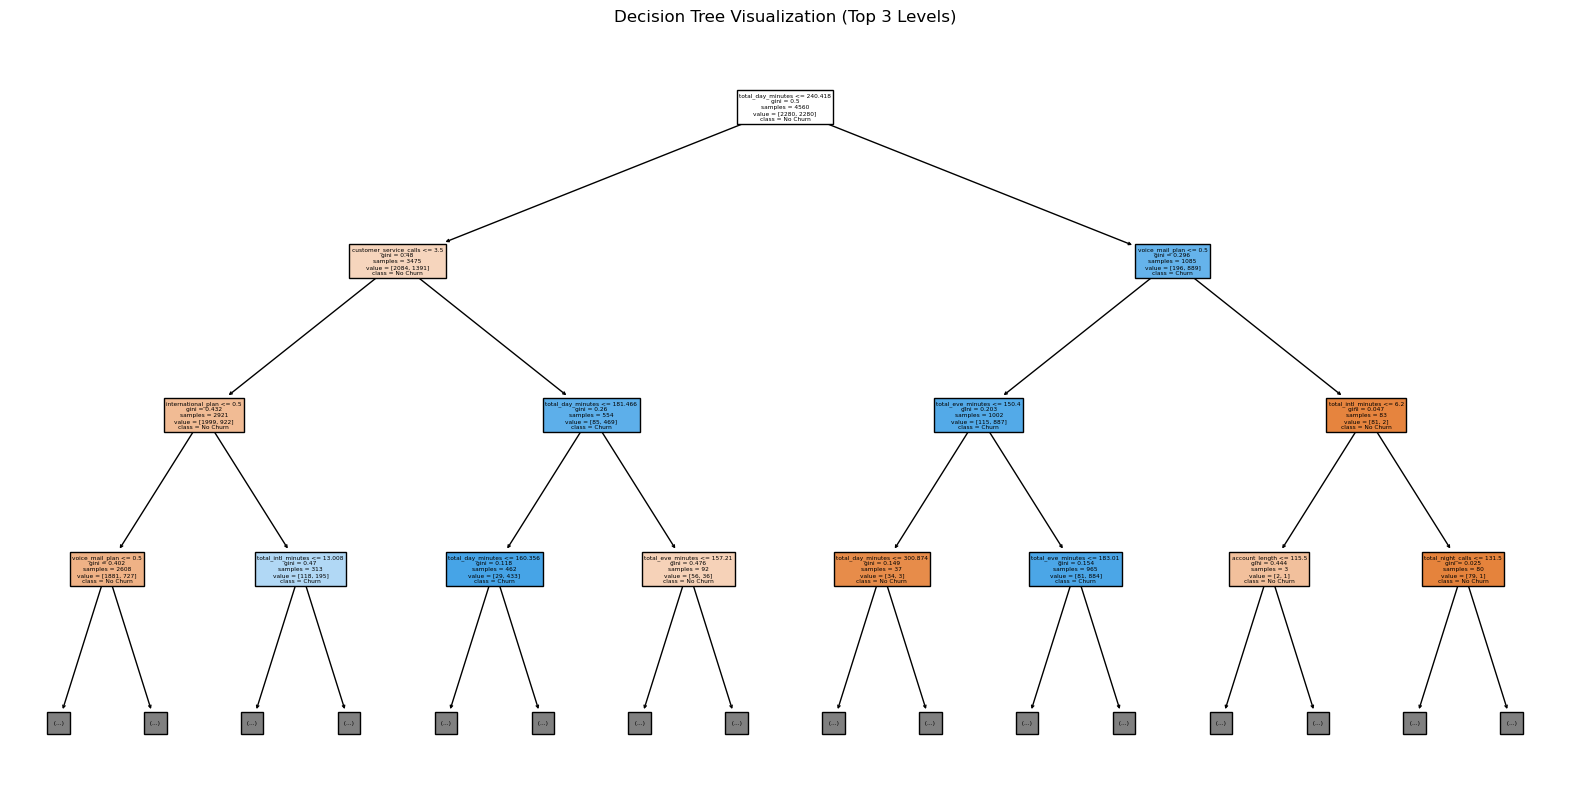

In [ ]:

plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, class_names=['No Churn', 'Churn'], filled=True, max_depth=3)
plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()


In [ ]:
joblib.dump(dtree, 'decision_tree_model.pkl')
print("Model saved as decision_tree_model.pkl")


Model saved as decision_tree_model.pkl


##  Recommendations

Based on the insights derived from the data and the performance of the models developed, we recommend the following actions for the telecom business:

1. **Target Customers Without International Plans**
   Our analysis showed a higher churn rate among customers without international calling plans. The business should consider bundling international plans with other services or offering promotional discounts to encourage uptake, which may increase customer retention.

2. **Address High Customer Support Interaction Early**
   Customers who made more customer service calls were significantly more likely to churn. This indicates unresolved issues or dissatisfaction. A proactive approach to customer service — such as follow-up calls, satisfaction surveys, or assigning support account managers — could reduce churn in this segment.

3. **Personalize Retention Strategies for Heavy Day/Night Callers**
   The usage patterns suggest that users with higher day or night call minutes may also be at risk. Tailored loyalty programs, better call rates, or bonus minutes could be used to incentivize these users to stay.

4. **Leverage Churn Predictions in CRM Workflows**
   With the model achieving an improved recall of 75.3%, the business can integrate this model into its CRM tools to identify high-risk customers in real-time and trigger personalized retention interventions for example, SMS, email offers, or exclusive call plans.

5. **Start Immediately with High-Risk Customer Targeting**
   Customers with high daytime usage and frequent support calls are clear churn risks. Early intervention through loyalty offers or priority support is essential.

6. **Implement Regional and Onboarding Strategies**
   States like New Jersey, California, and Texas show high churn. Regionalized campaigns and onboarding touchpoints for new customers may reduce early churn

7. **Implement Discounts for customers with high monthly charges**
  Customers with high monthly charges are more likely to churn, so offering tiered discounts or personalized, lower-cost bundles could improve retention among this group. Additionally, since customers with less than six months' tenure are at higher risk of churning, early retention strategies such as onboarding incentives and timely satisfaction surveys should be implemented to increase loyalty. 


##  Limitations

While the project successfully builds a predictive model for churn, it has several limitations:

1. **SMOTE May Lead to Overfitting**
   While SMOTE helped balance the training data, it creates synthetic samples that can make the model perform well on training but not generalize to new data if not carefully validated.

2. **Limited Model Diversity**
   Only three models were explored. Incorporating more advanced models and comparing their results could improve both accuracy and business insight.

3. **Unclear Behavioral Drivers**
   Some patterns  such as higher churn among international plan users  lack clear business explanations, suggesting missing features or external factors.

4. **Geographic Insights Not Fully Exploited**
   While churn varies by state, the models didn’t leverage location deeply. Adding more granular location data or regional behavior metrics could improve predictions.

5. **No Insight into Customer Support Outcomes**
   The number of customer service calls correlates with churn, but we lack data on whether those calls were resolved positively or not  a potentially critical variable.

6. **Model May Degrade Over Time**
   The telecom market is dynamic. Without frequent model retraining, prediction accuracy may decrease as customer preferences shift.


## Next Steps

To build on the current results and maximize business impact, the following steps are recommended:

1. **Explore Additional Models**  
   Implement and compare gradient boosting algorithms for example XGBoost, LightGBM and neural networks to improve predictive accuracy.

2. **Conduct A/B Testing**  
   Test various retention strategies informed by the model through controlled experiments to determine which interventions yield the highest ROI.
